# AgroPlus - Modelo L1 UPRA (CRISP-DM)
## Clasificador binario Papa vs no-Papa con XGBoost

Notebook dedicado al **modelo L1** del ensamble jerarquico AgroPlus.

| Aspecto | Valor |
|---------|-------|
| **Fuente de etiqueta** | `fuente == 'monitoreo'` (UPRA, ground truth pixel) |
| **Tarea** | Clasificacion binaria (`Papa` vs `no-Papa`) |
| **Modelo** | XGBoost binario con `scale_pos_weight` |
| **Metrica primaria** | ROC-AUC y PR-AUC (clases desbalanceadas) |
| **Resolucion** | 50 m / pixel-semestre |

**Rol en el ensamble:** L1 produce `P(Papa | x)` para todos los pixeles del area de estudio. En la etapa de stacking se combina con `P(cultivo | x)` de L2 (LLP-Co) y `P(no-apto | x)` de L3 (XGBoost SIPRA+NDVI).

**Justificacion del binario:** la fuente `monitoreo` solo tiene ground truth para Papa (UPRA monitorea Papa en el altiplano cundiboyacense). Modelar todos los cultivos simultaneamente con esta fuente sesgaria el modelo hacia el espacio Papa. La separacion en niveles permite usar la mejor etiqueta disponible para cada subproblema.


---
# 1. Comprension del Negocio

## 1.1 Objetivo
Predecir, para cada pixel-semestre del area de estudio, la **probabilidad de que el cultivo principal sea Papa**, usando solo las observaciones de monitoreo UPRA como datos de entrenamiento.

## 1.2 Por que un modelo dedicado para Papa
- **Cobertura geografica concentrada:** Papa se cultiva casi exclusivamente en la franja 2200-3200 msnm del altiplano cundiboyacense. Un modelo binario explota mejor esta firma topo-climatica que un multi-clase con 17 clases.
- **Calidad de etiqueta superior:** UPRA hace monitoreo predial con verificacion de campo (`confianza = 1.0`). El resto de fuentes (`eva_municipal`, `noapto_proxy`) son etiquetas blandas o proxies.
- **Ciclo distintivo:** Papa tiene dos cosechas anuales (semestres A y B) con dinamicas NDVI muy reconocibles, lo que ayuda a la separacion espectral.

## 1.3 Criterio de exito
- **PR-AUC > 0.85** en test (hold-out de municipios no vistos en training).
- **Recall@Precision=0.90 > 0.70** (capacidad de capturar al menos 70% de los pixeles Papa cuando exigimos 90% de precision).
- Sin fuga espacial: ningun municipio aparece en mas de un fold del split.


---
# 2. Comprension de los Datos


## 2.1 Imports


In [207]:
# Instalacion completa de dependencias del notebook ensamble.
# Cubre: numerico, viz, ML clasico, XGBoost, PyTorch, balanceo, optimizacion bayesiana.
# Nota: para PyTorch CUDA usar el comando especifico de https://pytorch.org/

%pip install -q "numpy>=1.24" "pandas>=2.0" "pyarrow>=14" "matplotlib>=3.8" "seaborn>=0.13" "scikit-learn>=1.4" "xgboost>=2.0" "imbalanced-learn>=0.12" "optuna>=3.6" "optuna-integration[sklearn]>=3.6" "torch>=2.0" "tqdm>=4.66" "nbformat>=5.9" "ipykernel>=6.29"

print("Dependencias instaladas. Reinicia el kernel si pytorch o matplotlib se actualizo.")

Note: you may need to restart the kernel to use updated packages.
Dependencias instaladas. Reinicia el kernel si pytorch o matplotlib se actualizo.


In [208]:
# Compatibilidad matplotlib >= 3.9 (referencia: notebook L2 LLP-Co)
import matplotlib._api as _mpl_api_compat
#if not hasattr(_mpl_api_compat, 'MatplotlibDeprecationWarning'):
#    class MatplotlibDeprecationWarning(DeprecationWarning):
#        pass
#    _mpl_api_compat.MatplotlibDeprecationWarning = MatplotlibDeprecationWarning

import warnings
#warnings.filterwarnings('ignore', category=FutureWarning)
#warnings.filterwarnings('ignore', category=DeprecationWarning)
#warnings.filterwarnings('ignore', category=UserWarning)

import os, json, time
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
mpl.style.use('ggplot')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
%matplotlib inline

from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report, accuracy_score,
    precision_score, recall_score, f1_score, log_loss, brier_score_loss
)

import xgboost as xgb
from xgboost import XGBClassifier

import optuna
import optuna.distributions as odist

np.random.seed(42)
pd.set_option('display.max_columns', 80)
pd.set_option('display.float_format', '{:.4f}'.format)

# GPU para XGBoost si esta disponible
try:
    test_dm = xgb.DMatrix(np.zeros((10, 2)), label=np.zeros(10))
    xgb.train({'tree_method': 'hist', 'device': 'cuda'}, test_dm, num_boost_round=1)
    XGB_DEVICE = 'cuda'
except Exception:
    XGB_DEVICE = 'cpu'
XGB_TREE_METHOD = 'hist'
XGB_N_JOBS = -1

print(f'NumPy {np.__version__} | Pandas {pd.__version__} | XGBoost {xgb.__version__}')
print(f'XGBoost device: {XGB_DEVICE}')


NumPy 2.4.4 | Pandas 3.0.2 | XGBoost 3.2.0
XGBoost device: cuda


## 2.2 Carga de la vista minable


In [209]:
DATA_DIR = Path('../vista_minable')
CKPT_DIR = Path('checkpoints')
CKPT_DIR.mkdir(exist_ok=True)

DATA_PATH     = DATA_DIR / 'vista_minable_full.parquet'
CATALOGO_PATH = DATA_DIR / 'catalogo_cultivos.json'

df_raw = pd.read_parquet(DATA_PATH)
with open(CATALOGO_PATH, 'r', encoding='utf-8') as f:
    catalogo = json.load(f)

print(f'Vista minable: {df_raw.shape[0]:,} filas x {df_raw.shape[1]} columnas')
print(f'Catalogo de cultivos: {len(catalogo)} clases')


Vista minable: 4,164,485 filas x 77 columnas
Catalogo de cultivos: 20 clases


In [210]:
df_raw.head()

,pixel_id,x,y,semestre,cod_mun,elevacion,pendiente,twi,sg_phh2o,sg_soc,sg_nitrogen,sg_cec,sg_bdod,sg_clay,sg_sand,sg_silt,igac_fertilidad,igac_fosforo,igac_ph,igac_potasio,igac_vocacion,piso_termico,indice_fertilidad,aspecto_sin,aspecto_cos,ndvi_sigma_temporal,ndvi_mean_temporal,temperatura_media,temperatura_max,temperatura_min,humedad_media,chirps_acum,s2_ndvi_media,s2_ndvi_max,s2_ndvi_std,s2_gndvi_media,s2_gndvi_max,s2_gndvi_std,s2_msavi_media,s2_msavi_max,s2_msavi_std,s2_bsi_media,s2_bsi_max,s2_bsi_std,s2_savi_media,s2_savi_max,s2_savi_std,amplitud_termica,anomalia_precip,ndvi_max,ndvi_integral,indice_aridez,cultivo,cultivo_id,confianza,fuente,rendimiento_tha,prob_Papa,prob_Cana_Panelera,prob_Cafe,prob_Maiz,prob_Platano,prob_Mango,prob_Frijol,prob_Cacao,prob_Arveja,prob_Palma,prob_Banano,prob_Citricos,prob_Mora,prob_Zanahoria,prob_Tomate_Arbol,prob_Yuca,prob_Habichuela,prob_Hortalizas,prob_Otros_cultivos,prob_No_apto
0,0,1107022.7366,1137622.5453,2020A,0,3009.6982,12.5241,20.0455,5.5000,9.7500,5.3200,2.5800,1.0600,29.0000,30.0000,40.0000,3.0000,1.0000,1.0000,1.0000,5.0000,3.0000,0.6507,-0.8811,0.4730,0.0158,0.8256,-0.6050,-0.0890,-1.3440,69.5540,372.1031,0.5355,0.7516,0.1087,0.5041,0.6270,0.0657,0.3156,0.5122,0.1162,0.0111,0.2292,0.1733,0.3359,0.5101,0.1037,1.2550,-1.2699,0.7516,96.3826,3.0764,No_apto,19,0.4000,noapto_proxy,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
1,1,1060221.1597,1137572.5366,2020A,0,2174.9927,13.8300,19.6552,5.4000,7.5100,4.6800,2.3700,0.9400,40.0000,31.0000,28.0000,3.0000,1.0000,1.0000,1.0000,3.0000,2.0000,0.5284,0.8365,-0.5480,0.0340,0.7925,3.6222,4.3000,3.0504,69.5540,730.4546,0.5947,0.8010,0.2586,0.5242,0.7299,0.2450,0.4136,0.5691,0.1726,-0.1860,-0.1262,0.0495,0.4130,0.5531,0.1688,1.2496,-1.9118,0.8010,107.0441,4.8579,No_apto,19,0.4000,noapto_proxy,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
2,2,1062471.2355,1137572.5366,2020A,0,2325.3787,11.0770,20.5380,5.3000,8.3600,3.9500,2.5700,0.9700,37.0000,31.0000,31.0000,3.0000,1.0000,1.0000,1.0000,7.0000,2.0000,0.5255,0.9380,0.3466,0.0196,0.8655,2.7806,3.4366,2.2582,69.5540,733.9651,0.5619,0.6604,0.1205,0.5396,0.6305,0.1129,0.2708,0.2974,0.0268,-0.0288,-0.0057,0.0199,0.3019,0.3325,0.0317,1.1784,-1.9009,0.6604,101.1445,5.2322,No_apto,19,0.4000,noapto_proxy,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
3,4,1071271.5320,1137572.5366,2020A,0,2059.6421,0.6440,23.8345,5.6000,5.0900,4.2600,2.4400,1.0300,33.0000,31.0000,35.0000,3.0000,1.0000,1.0000,1.0000,6.0000,2.0000,0.4658,0.9470,-0.3213,0.0297,0.7745,4.4441,5.0226,4.0970,69.5540,730.7438,0.6330,0.7346,0.0618,0.5935,0.6931,0.0673,0.3890,0.4479,0.0388,-0.0889,-0.0517,0.0355,0.4066,0.4594,0.0342,0.9256,-1.7224,0.7346,113.9380,5.4381,No_apto,19,0.4000,noapto_proxy,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
4,5,1071821.5506,1137572.5366,2020A,0,2060.9927,1.5970,21.4907,5.4000,6.4800,4.4000,2.2600,1.0300,32.0000,30.0000,36.0000,3.0000,1.0000,1.0000,1.0000,6.0000,2.0000,0.4747,0.9181,0.3964,0.0130,0.7164,4.3788,4.9520,4.0370,69.5540,731.0130,0.7071,0.8185,0.1178,0.6292,0.7388,0.1105,0.5296,0.6003,0.0768,-0.2170,-0.1662,0.0425,0.5185,0.5747,0.0646,0.9151,-1.7058,0.8185,127.2868,5.4874,No_apto,19,0.4000,noapto_proxy,NaN,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000


In [211]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 4164485 entries, 0 to 4164484
Data columns (total 77 columns):
 #   Column               Dtype  
---  ------               -----  
 0   pixel_id             int64  
 1   x                    float64
 2   y                    float64
 3   semestre             str    
 4   cod_mun              int32  
 5   elevacion            float32
 6   pendiente            float32
 7   twi                  float32
 8   sg_phh2o             float32
 9   sg_soc               float32
 10  sg_nitrogen          float32
 11  sg_cec               float32
 12  sg_bdod              float32
 13  sg_clay              float32
 14  sg_sand              float32
 15  sg_silt              float32
 16  igac_fertilidad      float32
 17  igac_fosforo         float32
 18  igac_ph              float32
 19  igac_potasio         float32
 20  igac_vocacion        float32
 21  piso_termico         float32
 22  indice_fertilidad    float32
 23  aspecto_sin          float32
 24  aspecto_c

## 2.3 Filtrado a fuente UPRA y construccion del target binario

L1 usa `fuente in ['monitoreo', 'eva_municipal']`. El target binario es `1` si `cultivo == 'Papa'`, `0` en cualquier otro caso.

### PROBLEMA CRITICO: Separacion trivial por tipo de fuente

`noapto_proxy` son pixeles **no-agricolas** (SIPRA >=3 capas "No apta" Y/O NDVI_max < 0.15).
Incluirlos como negativos produce separacion perfecta (PR-AUC=1.0 desde la iteracion 0).
Solucion: **excluir `noapto_proxy`** del L1. Solo nos interesan negativos *agricoles*.


In [212]:
# =====================================================================
# CORRECCION v3: excluir noapto_proxy + RESTRICCION GEOGRAFICA.
#
# PROBLEMA RAIZ: fuente y target estan correlacionados por construccion:
#   monitoreo = poligonos UPRA -> altiplano (Papa, 2200-3200 msnm)
#   eva_municipal = resto de Cundinamarca -> zona baja/media
# El modelo aprende "altiplano vs resto", no agronomia real.
# Cualquier feature climatica da PR-AUC=1.0 trivialmente (70 trials v2).
#
# AJUSTE 1: filtrar eva_municipal al envelope altitudinal de Papa.
#   Negativos EVA solo si elevacion (o temperatura_media) en [Q5, Q95] Papa.
# AJUSTE 6: monitoreo no-Papa = negativos de oro (w=1.0, fuente UPRA).
# =====================================================================

fuentes_validas = ['monitoreo', 'eva_municipal']
df_l1_raw = df_raw[df_raw['fuente'].isin(fuentes_validas)].copy().reset_index(drop=True)
df_l1_raw['y'] = (df_l1_raw['cultivo'] == 'Papa').astype(np.int8)
df_l1_raw['_year'] = df_l1_raw['semestre'].str[:4].astype(int)
peso_por_fuente = {'monitoreo': 1.0, 'eva_municipal': 0.7}
df_l1_raw['sample_weight'] = df_l1_raw['fuente'].map(peso_por_fuente).astype(np.float32)

# --- AJUSTE 6: cultivos en monitoreo ---
mon_cultivos = df_l1_raw[df_l1_raw['fuente'] == 'monitoreo']['cultivo'].value_counts()
n_mon_papa  = int(((df_l1_raw['fuente'] == 'monitoreo') & (df_l1_raw['y'] == 1)).sum())
n_mon_other = int(((df_l1_raw['fuente'] == 'monitoreo') & (df_l1_raw['y'] == 0)).sum())
print('=== Cultivos en fuente monitoreo (UPRA) ===')
print(mon_cultivos.to_string())
print(f'Monitoreo Papa (y=1): {n_mon_papa:,}  |  no-Papa gold negatives (w=1.0): {n_mon_other:,}')

# --- AJUSTE 1: Envelope geografico (elevacion > temperatura_media como fallback) ---
GEO_FEAT = None
for cand in ['elevacion', 'temperatura_media']:
    if cand in df_l1_raw.columns and df_l1_raw[cand].notna().sum() > 100:
        GEO_FEAT = cand
        break

if GEO_FEAT is not None:
    pos_vals = df_l1_raw.loc[df_l1_raw['y'] == 1, GEO_FEAT].dropna()
    Q_LO, Q_HI = float(pos_vals.quantile(0.05)), float(pos_vals.quantile(0.95))
    rango = Q_HI - Q_LO
    Q_LO_EVA = Q_LO - 0.10 * rango   # 10% margen para no cortar hard-negatives marginales
    Q_HI_EVA = Q_HI + 0.10 * rango
    print(f'\nEnvelope Papa ({GEO_FEAT}): [{Q_LO:.2f}, {Q_HI:.2f}]')
    print(f'Ventana EVA (+-10%):       [{Q_LO_EVA:.2f}, {Q_HI_EVA:.2f}]')

    mask_mon = df_l1_raw['fuente'] == 'monitoreo'
    mask_eva = (df_l1_raw['fuente'] == 'eva_municipal') & \
               df_l1_raw[GEO_FEAT].between(Q_LO_EVA, Q_HI_EVA)

    n_eva_tot  = int((df_l1_raw['fuente'] == 'eva_municipal').sum())
    n_eva_ok   = int(mask_eva.sum())
    n_eva_excl = n_eva_tot - n_eva_ok
    df_l1 = df_l1_raw[mask_mon | mask_eva].copy().reset_index(drop=True)
    print(f'EVA total={n_eva_tot:,} | en envelope={n_eva_ok:,} | '
          f'excluidos={n_eva_excl:,} ({n_eva_excl/max(n_eva_tot,1)*100:.1f}%)')
else:
    print('ADVERTENCIA: sin feature geografico. Sin filtro de envelope.')
    df_l1 = df_l1_raw.copy()
    Q_LO = Q_HI = None

n_pos = int(df_l1['y'].sum())
n_neg = int((1 - df_l1['y']).sum())
masa_pos = df_l1.loc[df_l1['y'] == 1, 'sample_weight'].sum()
masa_neg = df_l1.loc[df_l1['y'] == 0, 'sample_weight'].sum()

print(f'\ndf_l1 post-restriccion: {len(df_l1):,} filas')
print(f'  monitoreo : {(df_l1["fuente"]=="monitoreo").sum():,} '
      f'(Papa={n_mon_papa:,}, no-Papa={int(((df_l1["fuente"]=="monitoreo")&(df_l1["y"]==0)).sum()):,})')
print(f'  EVA altiplano: {(df_l1["fuente"]=="eva_municipal").sum():,}')
print(f'Papa={n_pos:,} ({n_pos/len(df_l1)*100:.2f}%)  |  no-Papa={n_neg:,}')
print(f'Masa neg/pos = {masa_neg:.0f}/{masa_pos:.0f} = {masa_neg/max(masa_pos,1):.2f}')

# Diagnostico post-filtro
from scipy.stats import pointbiserialr
diag_feats = ([GEO_FEAT] if GEO_FEAT else []) + \
             [f for f in ['pendiente', 'piso_termico'] if f in df_l1.columns]
print('\n=== Post-filtro: point-biserial r con Papa ===')
for feat in diag_feats:
    if feat and feat in df_l1.columns and pd.api.types.is_numeric_dtype(df_l1[feat]):
        valid = df_l1[[feat, 'y']].dropna()
        if len(valid) > 10:
            r, _ = pointbiserialr(valid['y'], valid[feat])
            flag = '  *** REVISAR ***' if abs(r) > 0.90 else ''
            print(f'  {feat:<25} r={r:+.4f}{flag}')


=== Cultivos en fuente monitoreo (UPRA) ===
cultivo
Papa              486058
Otros_cultivos     79971
Monitoreo Papa (y=1): 486,058  |  no-Papa gold negatives (w=1.0): 79,971

Envelope Papa (elevacion): [2540.47, 3362.04]
Ventana EVA (+-10%):       [2458.31, 3444.20]
EVA total=2,990,171 | en envelope=2,280,771 | excluidos=709,400 (23.7%)

df_l1 post-restriccion: 2,846,800 filas
  monitoreo : 566,029 (Papa=486,058, no-Papa=79,971)
  EVA altiplano: 2,280,771
Papa=486,058 (17.07%)  |  no-Papa=2,360,742
Masa neg/pos = 1676510/486058 = 3.45

=== Post-filtro: point-biserial r con Papa ===
  elevacion                 r=+0.0662
  pendiente                 r=-0.0555
  piso_termico              r=+0.0255


## 2.4 Exploracion: balance, geografia y temporalidad


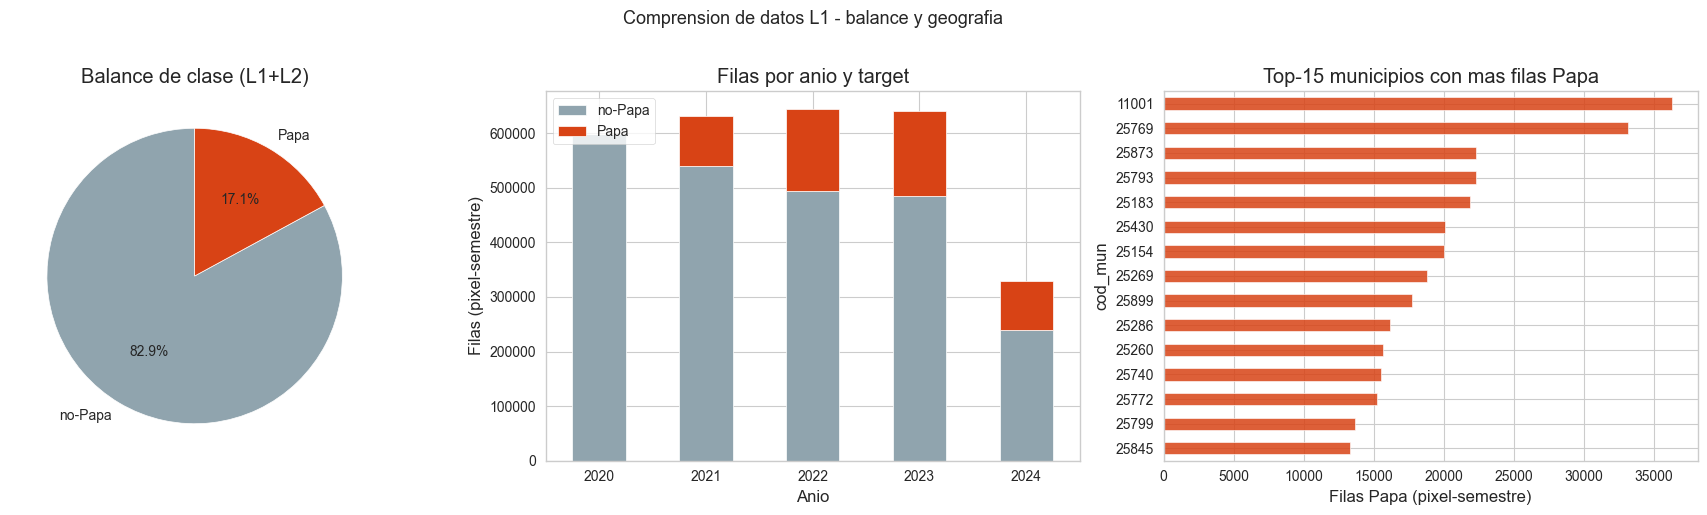

In [213]:
# === Visualizacion 1: balance de clase + distribucion por anio y municipio ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1a. Balance de clase
labels = ['no-Papa', 'Papa']
counts = [n_neg, n_pos]
axes[0].pie(counts, labels=labels, autopct='%1.1f%%',
            colors=['#90A4AE', '#D84315'], startangle=90)
axes[0].set_title('Balance de clase (L1+L2)')

# 1b. Distribucion por anio (desde columna _year / semestre)
year_target = df_l1.groupby(['_year', 'y']).size().unstack(fill_value=0)
year_target.columns = ['no-Papa', 'Papa']
year_target.plot(kind='bar', stacked=True, ax=axes[1],
                color=['#90A4AE', '#D84315'])
axes[1].set_title('Filas por anio y target')
axes[1].set_ylabel('Filas (pixel-semestre)')
axes[1].set_xlabel('Anio')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(loc='upper left')

# 1c. Top municipios por concentracion de Papa
mun_papa = df_l1[df_l1['y'] == 1]['cod_mun'].value_counts().head(15)
mun_papa.plot.barh(ax=axes[2], color='#D84315', alpha=0.85)
axes[2].set_title('Top-15 municipios con mas filas Papa')
axes[2].set_xlabel('Filas Papa (pixel-semestre)')
axes[2].invert_yaxis()

plt.suptitle('Comprension de datos L1 - balance y geografia', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

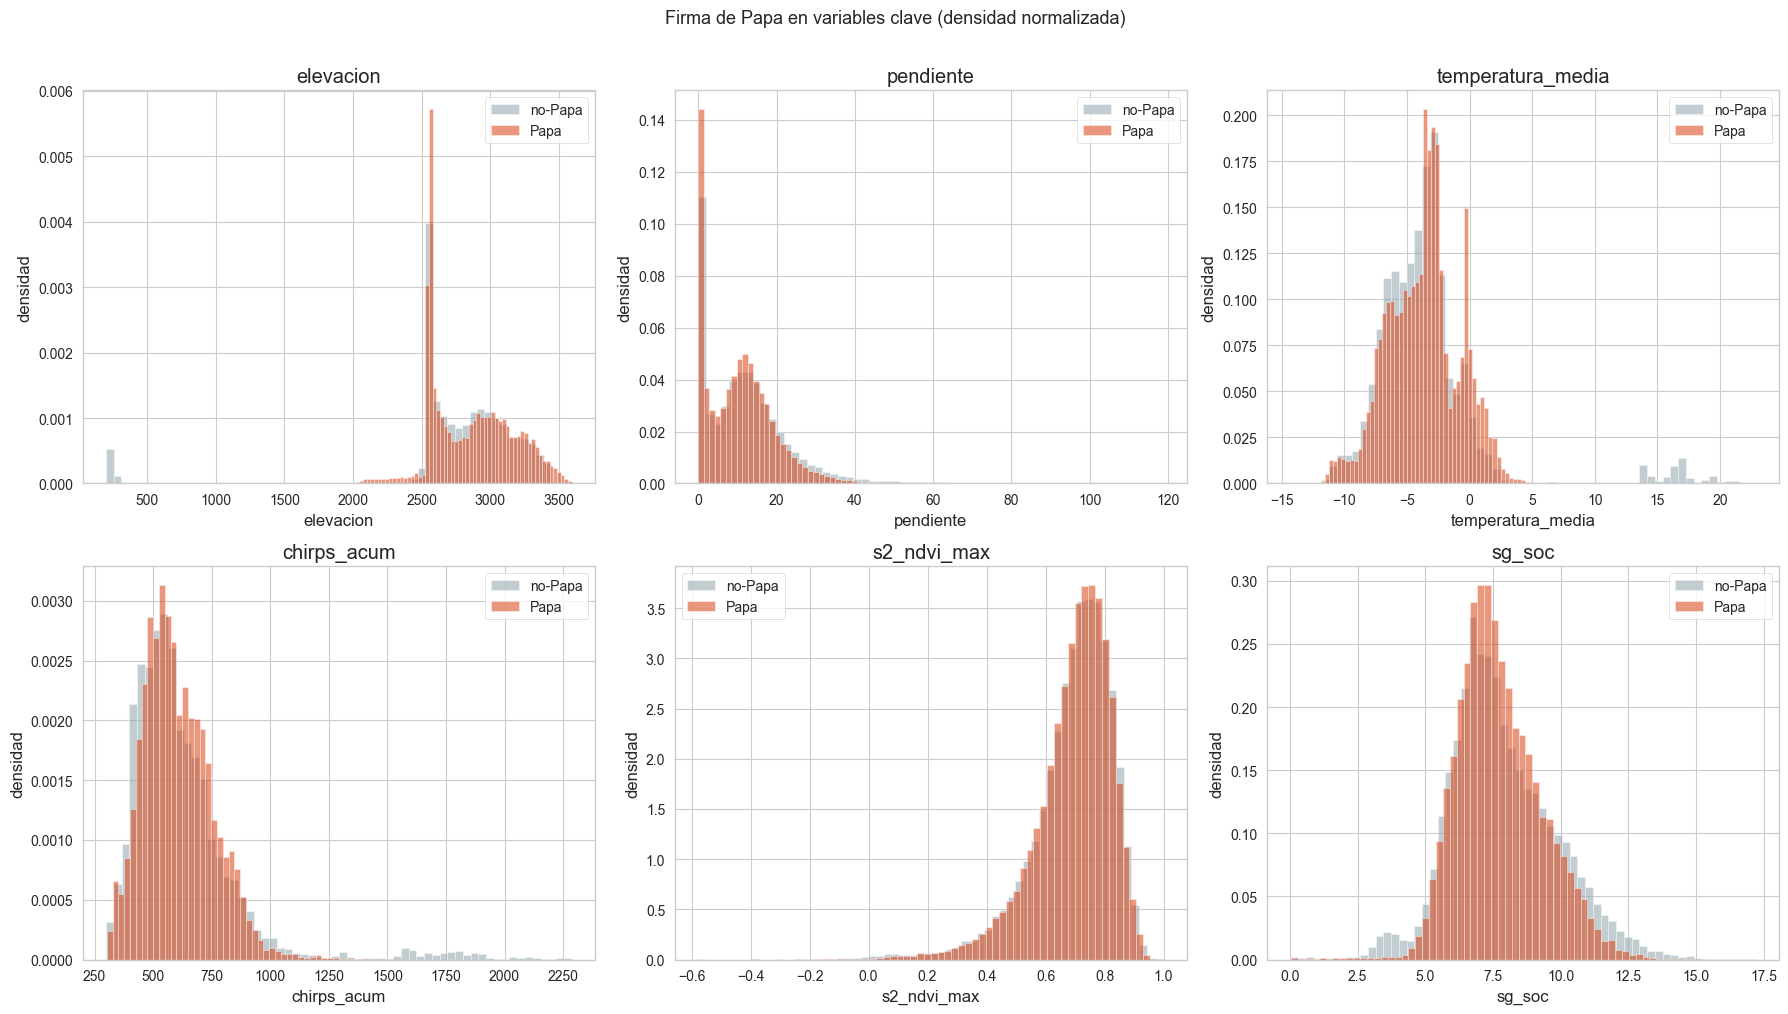

In [214]:
# === Visualizacion 2: firma topo-climatica de Papa vs no-Papa ===
features_clave = ['elevacion', 'pendiente', 'temperatura_media', 'chirps_acum',
                  's2_ndvi_max', 'sg_soc']
features_clave = [c for c in features_clave if c in df_l1.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, feat in zip(axes, features_clave):
    for clase, color, label in [(0, '#90A4AE', 'no-Papa'), (1, '#D84315', 'Papa')]:
        s = df_l1.loc[df_l1['y'] == clase, feat].dropna()
        if len(s) > 50_000:
            s = s.sample(50_000, random_state=42)
        ax.hist(s, bins=60, alpha=0.55, color=color, label=label, density=True)
    ax.set_title(f'{feat}')
    ax.set_xlabel(feat); ax.set_ylabel('densidad')
    ax.legend()

plt.suptitle('Firma de Papa en variables clave (densidad normalizada)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 2.5 Calidad de los datos


In [215]:
# Valores faltantes
missing = df_l1.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
if len(missing):
    print(f'Columnas con NaN: {len(missing)}')
    miss_pct = (df_l1[missing.index].isnull().mean() * 100).round(2)
    miss_df = pd.DataFrame({'n_missing': missing, 'pct': miss_pct})
    print(miss_df.head(20).to_string())
else:
    print('Sin valores faltantes en df_l1.')

print(f'\nTipos de datos:')
print(df_l1.dtypes.value_counts().to_string())


Columnas con NaN: 17
                     n_missing    pct
piso_termico             79971 2.8100
sg_clay                  22646 0.8000
sg_sand                  22646 0.8000
sg_silt                  22646 0.8000
s2_bsi_media             13223 0.4600
s2_bsi_max               13223 0.4600
s2_gndvi_max             13221 0.4600
s2_gndvi_media           13221 0.4600
s2_ndvi_max              13220 0.4600
s2_msavi_max             13220 0.4600
s2_savi_media            13220 0.4600
s2_ndvi_media            13220 0.4600
s2_msavi_media           13220 0.4600
s2_savi_max              13220 0.4600
ndvi_max                 13220 0.4600
ndvi_mean_temporal          18 0.0000
ndvi_sigma_temporal         18 0.0000

Tipos de datos:
float32    70
str         3
int64       2
float64     1
int8        1
int32       1
int16       1


## 2.6 Sanity check: deteccion de leakage geografico

Entrenamos XGBoost con **un solo feature geografico**. Si PR-AUC es cercano a 1.0
el modelo distingue el nicho geografico, no el cultivo. Este bloque corre
**antes y despues** del filtro de envelope para mostrar el impacto del Ajuste 1.

In [216]:
# =====================================================================
# SANITY CHECK: leakage geografico (Ajuste 5)
# Si PR-AUC con 1 feature es cercano a 1.0 -> leakage.
# Corrida ANTES del fix (df_l1_raw) y DESPUES (df_l1).
# =====================================================================
def _sanity_pr(df_in, geo_feat, label=''):
    if geo_feat not in df_in.columns:
        print(f'  {geo_feat}: no disponible')
        return None
    yr = df_in['_year'].values
    y_s = df_in['y'].values
    sw_s = df_in['sample_weight'].values
    X_s  = df_in[[geo_feat]].fillna(df_in[geo_feat].median()).values
    m_tr = yr <= 2022;  m_va = yr == 2023
    if m_tr.sum() < 10 or m_va.sum() < 10:
        print(f'  {geo_feat}: datos insuficientes para split')
        return None
    if len(np.unique(y_s[m_tr])) < 2 or len(np.unique(y_s[m_va])) < 2:
        print(f'  {geo_feat}: clase unica en un fold, skip')
        return None
    spw = sw_s[m_tr & (y_s==0)].sum() / max(sw_s[m_tr & (y_s==1)].sum(), 1)
    clf = XGBClassifier(n_estimators=300, max_depth=2, learning_rate=0.05,
                        scale_pos_weight=spw, eval_metric='aucpr',
                        early_stopping_rounds=20, random_state=42,
                        n_jobs=-1, verbosity=0, tree_method='hist')
    clf.fit(X_s[m_tr], y_s[m_tr], sample_weight=sw_s[m_tr],
            eval_set=[(X_s[m_va], y_s[m_va])],
            sample_weight_eval_set=[sw_s[m_va]], verbose=False)
    pr = average_precision_score(y_s[m_va], clf.predict_proba(X_s[m_va])[:,1],
                                 sample_weight=sw_s[m_va])
    tag = 'LEAKAGE ***' if pr > 0.80 else ('revisar' if pr > 0.60 else 'OK')
    print(f'  {label:<25} {geo_feat:<22} PR-AUC = {pr:.4f}  [{tag}]')
    return pr

print('--- Sanity check con 1 feature geografico ---')
feats_geo = ['temperatura_media', 'elevacion', 'piso_termico', 'indice_aridez']

print('\n[ANTES del filtro - df_l1_raw]')
for feat in feats_geo:
    _sanity_pr(df_l1_raw, feat, label='SIN envelope')

print('\n[DESPUES del filtro - df_l1]')
for feat in feats_geo:
    _sanity_pr(df_l1, feat, label='CON envelope')

print('\nObjetivo: PR-AUC < 0.70 con 1 feature geografico tras el filtro.')
print('Si sigue > 0.80, ampliar el filtro de envelope o excluir ese feature.')


--- Sanity check con 1 feature geografico ---

[ANTES del filtro - df_l1_raw]
  SIN envelope              temperatura_media      PR-AUC = 0.3141  [OK]
  SIN envelope              elevacion              PR-AUC = 0.3308  [OK]
  SIN envelope              piso_termico           PR-AUC = 0.2988  [OK]
  SIN envelope              indice_aridez          PR-AUC = 0.2430  [OK]

[DESPUES del filtro - df_l1]
  CON envelope              temperatura_media      PR-AUC = 0.3411  [OK]
  CON envelope              elevacion              PR-AUC = 0.4030  [OK]
  CON envelope              piso_termico           PR-AUC = 0.3294  [OK]
  CON envelope              indice_aridez          PR-AUC = 0.3166  [OK]

Objetivo: PR-AUC < 0.70 con 1 feature geografico tras el filtro.
Si sigue > 0.80, ampliar el filtro de envelope o excluir ese feature.


---
# 3. Preparacion de los Datos


## 3.1 Columnas excluidas

Tras la agregacion por ubicacion unica (Estrategia #4), ya no existen las columnas `semestre`, `semestre_cos`, `year_norm`. La columna `year_max` (ultimo anio con datos del pixel) se usa exclusivamente para el split temporal (Estrategia #1) y se excluye del vector de features para evitar fuga de informacion temporal.

In [217]:
# =====================================================================
# Columnas excluidas del vector de features.
# =====================================================================

EXCLUDE_COLS = [
    # Identificadores y geometria
    'x', 'y', 'cod_mun', 'pixel_id',
    # Target y metadatos de etiquetado
    'cultivo', 'cultivo_id', 'confianza', 'fuente', 'rendimiento_tha',
    # Temporal (se usa _year para split, no como feature)
    'semestre', '_year',
    # Redundancias conocidas
    'temperatura_max', 'temperatura_min',
    's2_savi_media', 's2_savi_max', 's2_savi_std',
    'ndvi_max',
    # LEAKAGE TEMPORAL: constantes por pixel calculadas sobre 2020-2024.
    # Misma constante en train y valid -> fingerprint directo del pixel.
    'ndvi_sigma_temporal',
    'ndvi_mean_temporal',
    # Proxy de nicho geografico global (cuasi-constante en altiplano)
    'piso_termico',
    # LEAKAGE DIRECTO DE TARGET: columnas prob_* son la distribucion
    # de probabilidad sobre cultivos asignada por el etiquetador.
    # prob_Papa = P(Papa) es esencialmente el target directamente.
    # Se excluyen todas usando un patron al inicio de feature_cols.
]

# Excluir adicionalmente cualquier columna prob_* en tiempo de ejecucion
# (los nombres exactos dependen del catalogo de cultivos)
_PROB_PREFIX = 'prob_'

print(f'EXCLUDE_COLS base: {len(EXCLUDE_COLS)} columnas')


EXCLUDE_COLS base: 20 columnas


## 3.2 Seleccion de variables - varianza y correlacion

Doble filtro:

1. **Varianza minima** - elimina variables cuasi-constantes (clase modal > 80%) cuyo r de Pearson colapsa a 0 con el resto por artefacto estadistico.
2. **Correlacion** - para cada par con `|r| > 0.85` se elimina la variable mas conectada con el resto (mayor correlacion media), reduciendo redundancia antes del entrenamiento.


In [218]:
# Definicion inicial de feature_cols (todo lo no excluido)
TARGET_COL = 'y'
EXCLUDE_COLS_FULL = list(set(EXCLUDE_COLS) | {TARGET_COL})
feature_cols = [c for c in df_l1.columns
                if c not in EXCLUDE_COLS_FULL
                and not c.startswith(_PROB_PREFIX)]
print(f'Features iniciales: {len(feature_cols)}')

# Muestra para acelerar el calculo de correlaciones
SAMPLE_CORR = 80_000
rng_corr = np.random.default_rng(42)
n_sample = min(SAMPLE_CORR, len(df_l1))
idx_sample = rng_corr.choice(len(df_l1), n_sample, replace=False)
df_sample = df_l1.iloc[idx_sample][feature_cols].copy()

# Imputar NaN con mediana para no romper el calculo de Pearson
for col in df_sample.columns:
    if df_sample[col].isna().any():
        df_sample[col] = df_sample[col].fillna(df_sample[col].median())

# --- Filtro 1: varianza minima ---
MIN_VARIANCE_PCT = 0.80
vars_cuasi_const = []
for col in df_sample.columns:
    top_freq = df_sample[col].value_counts(normalize=True).iloc[0]
    if top_freq > MIN_VARIANCE_PCT:
        vars_cuasi_const.append(col)

if vars_cuasi_const:
    print(f'\nVariables cuasi-constantes excluidas (>{MIN_VARIANCE_PCT*100:.0f}% en clase modal):')
    for v in vars_cuasi_const:
        top_freq = df_sample[v].value_counts(normalize=True).iloc[0]
        print(f'  {v:<30} (clase modal = {top_freq*100:.1f}%)')
    feature_cols = [c for c in feature_cols if c not in vars_cuasi_const]
    df_sample = df_sample.drop(columns=vars_cuasi_const)

# --- Filtro 2: correlacion ---
CORR_THRESH = 0.85
corr_matrix = df_sample.corr(method='pearson')
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape, dtype=bool), k=1))
high_corr_pairs = (
    upper.stack().reset_index()
    .rename(columns={'level_0': 'var_a', 'level_1': 'var_b', 0: 'corr'})
    .assign(abs_corr=lambda d: d['corr'].abs())
    .query('abs_corr > @CORR_THRESH')
    .sort_values('abs_corr', ascending=False)
)

vars_eliminar = set()
mean_corr = corr_matrix.abs().mean()
for _, row_p in high_corr_pairs.iterrows():
    a, b = row_p.var_a, row_p.var_b
    if a in vars_eliminar or b in vars_eliminar:
        continue
    eliminar = a if mean_corr[a] >= mean_corr[b] else b
    vars_eliminar.add(eliminar)

if len(vars_eliminar):
    print(f'\nPares con |r| > {CORR_THRESH}: {len(high_corr_pairs)}')
    print(f'Variables eliminadas por colinealidad: {len(vars_eliminar)}')
    for v in sorted(vars_eliminar):
        print(f'  {v}')

feature_cols = [c for c in feature_cols if c not in vars_eliminar]
print(f'\nFeatures finales: {len(feature_cols)}')


Features iniciales: 39

Variables cuasi-constantes excluidas (>80% en clase modal):
  igac_fosforo                   (clase modal = 97.2%)
  sample_weight                  (clase modal = 80.2%)

Pares con |r| > 0.85: 19
Variables eliminadas por colinealidad: 10
  elevacion
  s2_bsi_media
  s2_bsi_std
  s2_gndvi_media
  s2_msavi_media
  s2_msavi_std
  s2_ndvi_max
  s2_ndvi_media
  s2_ndvi_std
  sg_nitrogen

Features finales: 27


## 3.3b Escaneo de leakage por feature individual

Por cada feature superviviente, entrenamos XGBoost con ESE SOLO feature y medimos
PR-AUC en validacion. Cualquier feature que supere `LEAKAGE_THRESHOLD` sola es
sospechosa de leakage y se excluye automaticamente antes de proceder al modelado.

In [219]:
# =====================================================================
# ESCANEO AUTOMATICO DE LEAKAGE: PR-AUC con 1 feature a la vez
# Umbral: PR-AUC > LEAKAGE_THRESHOLD → feature excluido automaticamente
# =====================================================================
LEAKAGE_THRESHOLD = 0.70   # PR-AUC con 1 feature que ya implica leakage

yr = df_l1['_year'].values
y_all = df_l1['y'].values
sw_all = df_l1['sample_weight'].values
m_tr_sc = yr <= 2022
m_va_sc = yr == 2023

leakers_detectados = []
scan_results = []

if m_tr_sc.sum() < 20 or m_va_sc.sum() < 20 or \
   len(np.unique(y_all[m_tr_sc])) < 2 or len(np.unique(y_all[m_va_sc])) < 2:
    print('Split insuficiente para escaneo; verificar datos.')
else:
    # Imputar con mediana del train para el escaneo
    df_scan = df_l1[feature_cols].copy()
    for col in feature_cols:
        med = df_scan.loc[m_tr_sc, col].median()
        df_scan[col] = df_scan[col].fillna(med)

    spw_sc = sw_all[m_tr_sc & (y_all==0)].sum() / \
             max(sw_all[m_tr_sc & (y_all==1)].sum(), 1)

    for feat in feature_cols:
        X_f = df_scan[[feat]].values
        clf = XGBClassifier(
            n_estimators=200, max_depth=2, learning_rate=0.05,
            scale_pos_weight=spw_sc, eval_metric='aucpr',
            early_stopping_rounds=20, random_state=42,
            n_jobs=-1, verbosity=0, tree_method='hist'
        )
        clf.fit(X_f[m_tr_sc], y_all[m_tr_sc],
                sample_weight=sw_all[m_tr_sc],
                eval_set=[(X_f[m_va_sc], y_all[m_va_sc])],
                sample_weight_eval_set=[sw_all[m_va_sc]],
                verbose=False)
        pr = average_precision_score(
            y_all[m_va_sc], clf.predict_proba(X_f[m_va_sc])[:,1],
            sample_weight=sw_all[m_va_sc])
        scan_results.append({'feature': feat, 'pr_auc_solo': pr})
        if pr > LEAKAGE_THRESHOLD:
            leakers_detectados.append(feat)

    scan_df = pd.DataFrame(scan_results).sort_values('pr_auc_solo', ascending=False)
    print(f'Escaneo completado. Features: {len(feature_cols)}  |  '
          f'Leakers (PR-AUC > {LEAKAGE_THRESHOLD}): {len(leakers_detectados)}')
    print(f'\nTop-20 features por PR-AUC solitario:')
    print(scan_df.head(20).to_string(index=False))

    if leakers_detectados:
        print(f'\n*** LEAKERS DETECTADOS Y EXCLUIDOS AUTOMATICAMENTE: ***')
        for f in leakers_detectados:
            pr_val = scan_df.loc[scan_df['feature']==f, 'pr_auc_solo'].values[0]
            print(f'  {f:<35} PR-AUC solo = {pr_val:.4f}')
        feature_cols = [c for c in feature_cols if c not in leakers_detectados]
        print(f'\nFeatures restantes tras exclusion de leakers: {len(feature_cols)}')
    else:
        print('\nSin leakers individuales detectados. Continuando.')


Escaneo completado. Features: 27  |  Leakers (PR-AUC > 0.7): 0

Top-20 features por PR-AUC solitario:
          feature  pr_auc_solo
           sg_soc       0.3545
         sg_phh2o       0.3488
temperatura_media       0.3411
          sg_bdod       0.3400
        pendiente       0.3384
          sg_silt       0.3343
indice_fertilidad       0.3339
     s2_gndvi_std       0.3339
           sg_cec       0.3311
 amplitud_termica       0.3304
    ndvi_integral       0.3298
          sg_sand       0.3284
     s2_msavi_max       0.3263
          igac_ph       0.3257
    igac_vocacion       0.3237
     igac_potasio       0.3216
  igac_fertilidad       0.3212
      aspecto_sin       0.3205
              twi       0.3205
       s2_bsi_max       0.3205

Sin leakers individuales detectados. Continuando.


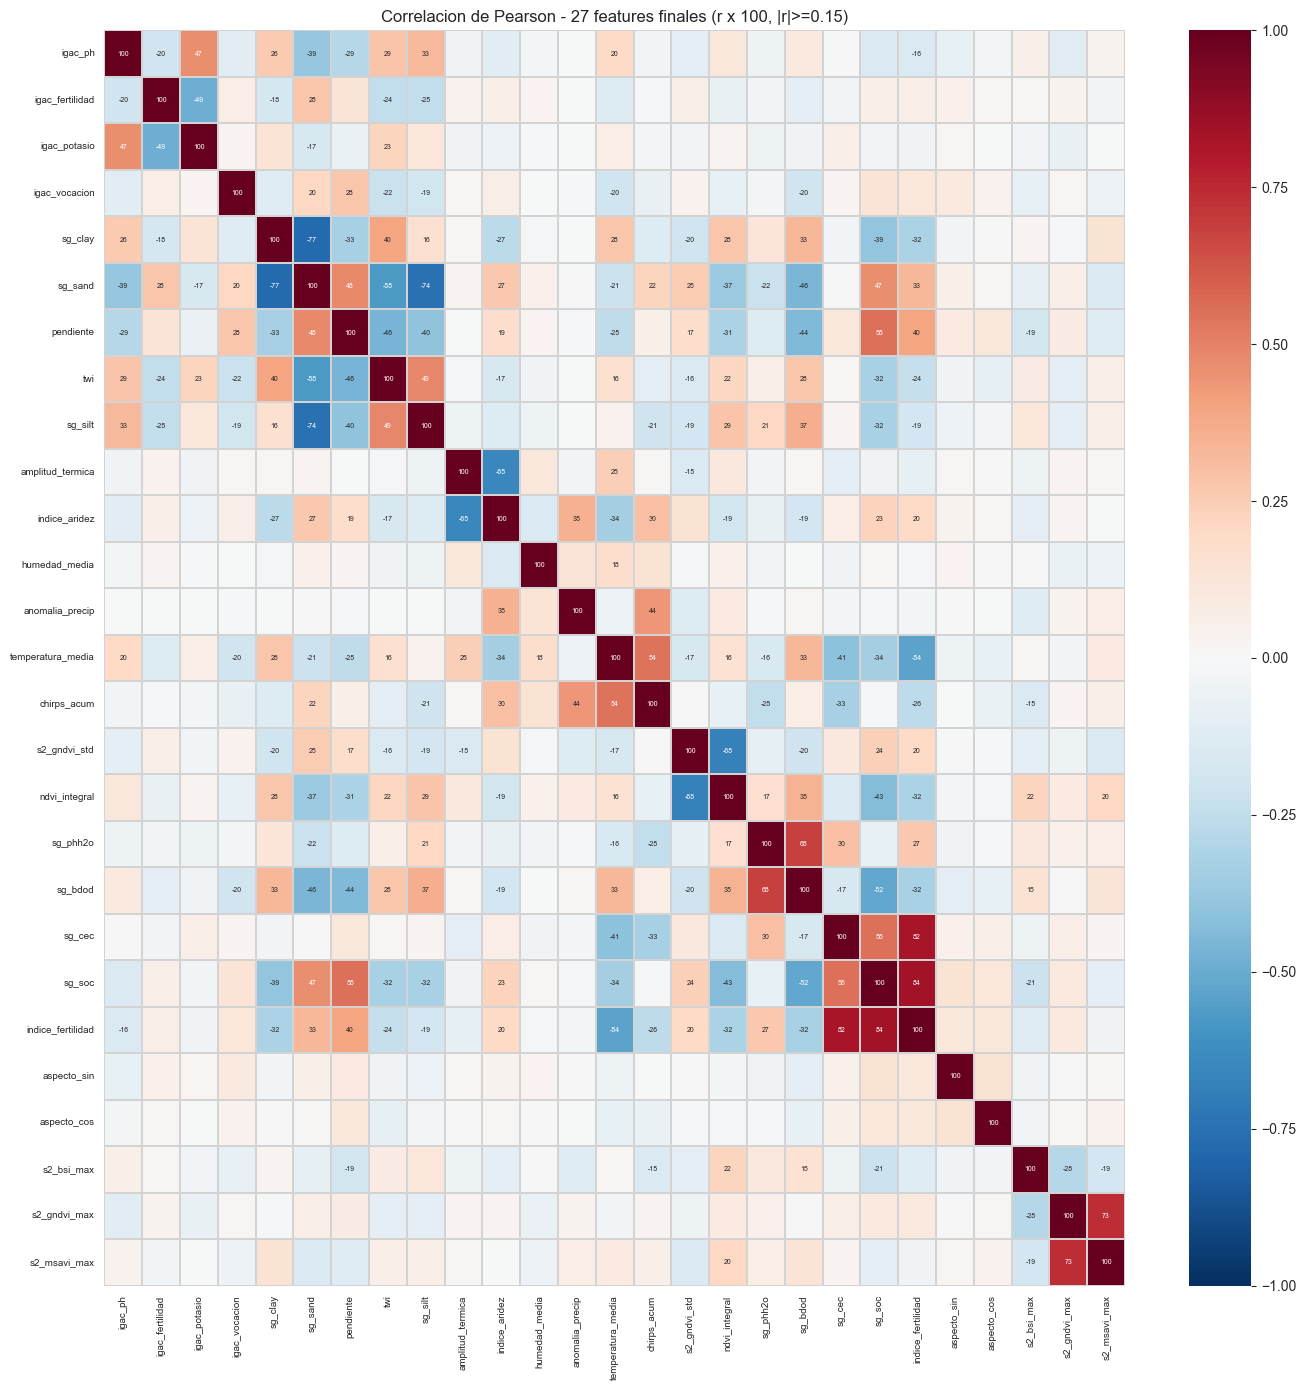

In [220]:
# === Visualizacion del mapa de correlacion final ===
import scipy.cluster.hierarchy as sch
from scipy.spatial.distance import squareform

corr_final = df_sample[feature_cols].corr(method='pearson')
dist = np.clip(1 - corr_final.abs(), 0, None)
linkage = sch.linkage(squareform(dist), method='ward')
order = sch.leaves_list(linkage)
cols_ord = corr_final.columns[order].tolist()
corr_ord = corr_final.loc[cols_ord, cols_ord]

n_feat = len(cols_ord)
fs = max(14, n_feat * 0.45)
fig, ax = plt.subplots(figsize=(fs, fs))

annot_data = (corr_ord * 100).round(0).astype(int).astype(str)
annot_data[corr_ord.abs() < 0.15] = ''

sns.heatmap(corr_ord, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=annot_data, fmt='', annot_kws={'size': max(5, int(160/n_feat))},
            linewidths=0.2, linecolor='lightgray')
ax.set_title(f'Correlacion de Pearson - {n_feat} features finales (r x 100, |r|>=0.15)',
             fontsize=12)
ax.tick_params(axis='x', rotation=90, labelsize=max(7, int(180/n_feat)))
ax.tick_params(axis='y', rotation=0, labelsize=max(7, int(180/n_feat)))
plt.tight_layout()
plt.show()


## 3.3 Relevancia univariada de cada variable frente al target

Diagnostico complementario al filtro de correlacion: medimos la relacion entre cada feature y la etiqueta binaria con dos metricas - `point-biserial r` (lineal) y `mutual information` (no lineal). Ambas se calculan sobre la muestra estratificada para que sean comparables al heatmap anterior.


Top-15 features por Mutual Information:
          feature  point_biserial_r  mutual_info  abs_r
    humedad_media            0.2126       0.0432 0.2126
  anomalia_precip            0.0898       0.0163 0.0898
temperatura_media           -0.0137       0.0131 0.0137
 amplitud_termica            0.0660       0.0118 0.0660
     igac_potasio           -0.0258       0.0108 0.0258
         sg_phh2o            0.0529       0.0085 0.0529
      chirps_acum           -0.0345       0.0083 0.0345
    indice_aridez           -0.0635       0.0080 0.0635
           sg_soc           -0.0173       0.0068 0.0173
  igac_fertilidad           -0.0032       0.0064 0.0032
    ndvi_integral            0.0876       0.0058 0.0876
indice_fertilidad            0.0344       0.0057 0.0344
          sg_bdod            0.0230       0.0054 0.0230
           sg_cec            0.0499       0.0052 0.0499
          igac_ph            0.0245       0.0049 0.0245


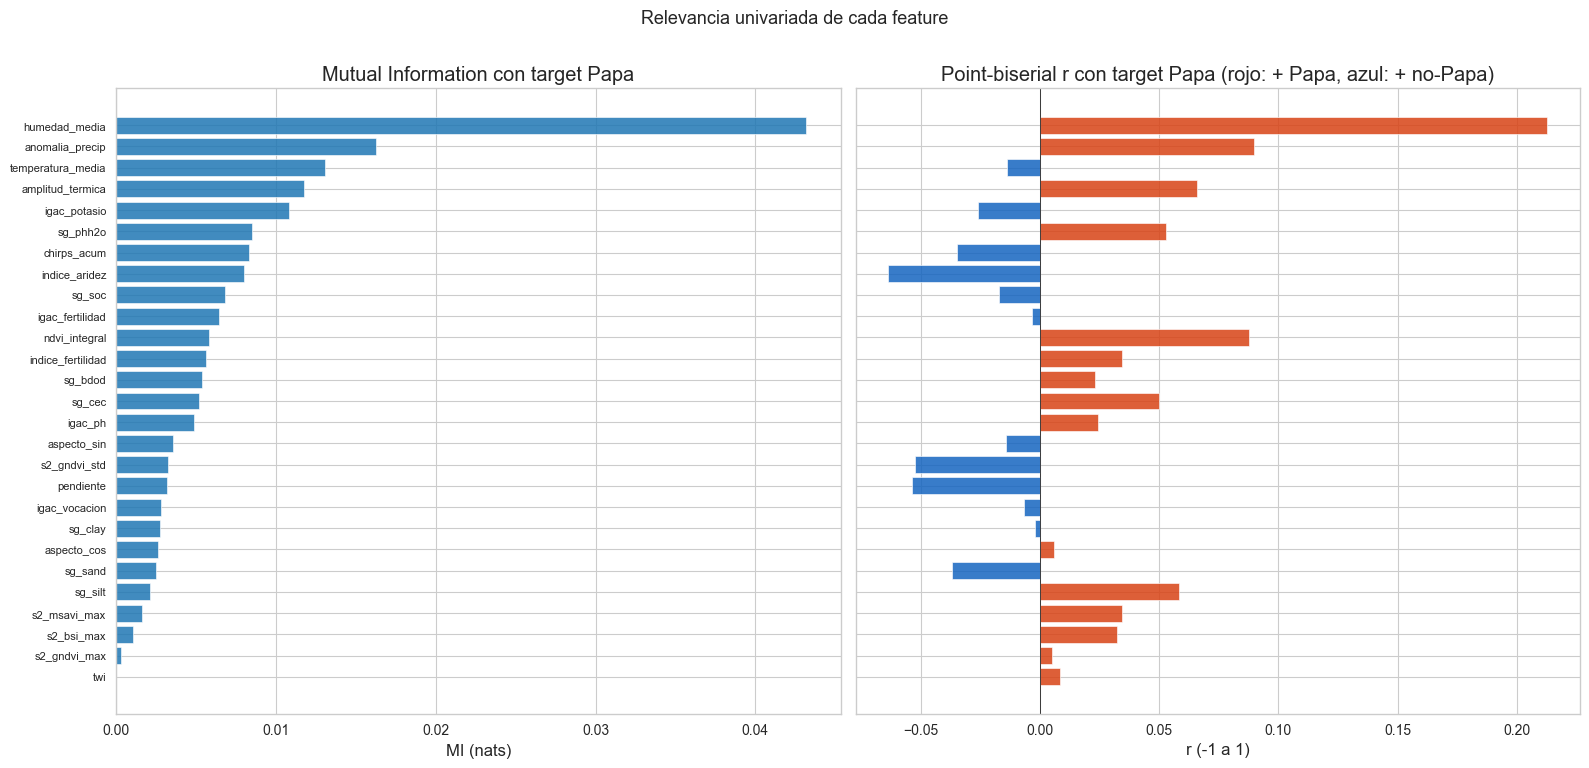

In [221]:
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import pointbiserialr

y_sample = df_l1.iloc[idx_sample][TARGET_COL].values
X_sample = df_sample[feature_cols].values  # ya imputado arriba

# Mutual information (no lineal). discrete_features=False asume continuas.
mi = mutual_info_classif(X_sample, y_sample, discrete_features=False, random_state=42)

# Point-biserial (Pearson contra binario)
pb = []
for j, col in enumerate(feature_cols):
    r, _ = pointbiserialr(X_sample[:, j], y_sample)
    pb.append(r)

rel_df = pd.DataFrame({
    'feature': feature_cols,
    'point_biserial_r': pb,
    'mutual_info': mi,
}).assign(abs_r=lambda d: d['point_biserial_r'].abs())   .sort_values('mutual_info', ascending=False)

print('Top-15 features por Mutual Information:')
print(rel_df.head(15).to_string(index=False))

# Visualizacion: dos paneles ordenados por MI
fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(feature_cols) * 0.28)))
order_feat = rel_df['feature'].tolist()
axes[0].barh(order_feat, rel_df['mutual_info'], color='#1f77b4', alpha=0.85)
axes[0].set_title('Mutual Information con target Papa')
axes[0].set_xlabel('MI (nats)')
axes[0].invert_yaxis()
axes[0].tick_params(axis='y', labelsize=8)

colors_pb = ['#D84315' if r > 0 else '#1565C0' for r in rel_df['point_biserial_r']]
axes[1].barh(order_feat, rel_df['point_biserial_r'], color=colors_pb, alpha=0.85)
axes[1].axvline(0, color='black', linewidth=0.5)
axes[1].set_title('Point-biserial r con target Papa (rojo: + Papa, azul: + no-Papa)')
axes[1].set_xlabel('r (-1 a 1)')
axes[1].invert_yaxis()
axes[1].set_yticklabels([])

plt.suptitle('Relevancia univariada de cada feature', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 3.4 Particion temporal por anio

**Split temporal estricto:** train en 2020-2022, valid en 2023, test en 2024.

Esto rompe la fuga temporal: el modelo debe generalizar a anios no vistos. Un pixel que fue Papa en 2020 y 2022 solo aparece en train; el modelo no puede memorizar "este pixel = Papa" porque en test hay pixeles nuevos que nunca vio en ningun anio de entrenamiento.

Ademas, mantenemos la verificacion de que ningun municipio aparezca en mas de un fold (fuga espacial), aunque el split primario es temporal.

In [222]:
# =====================================================================
# SPLIT ESPACIAL POR MUNICIPIO (reemplaza split temporal)
#
# CAUSA RAIZ DEL OVERFITTING RESIDUAL:
#   Split temporal (train<=2022, valid=2023) permite que el MISMO PIXEL
#   aparezca en train y en valid con features estaticos IDENTICOS.
#   Los 27 features restantes (suelo + topografia + IGAC + clima) forman
#   un fingerprint unico por pixel. El modelo memoriza los Papa pixels
#   en 2-3 arboles y los reconoce perfectamente en valid.
#
# SOLUCION: GroupShuffleSplit por cod_mun -> cero solapamiento de pixeles.
# =====================================================================

X = df_l1[feature_cols].copy()
y = df_l1[TARGET_COL].astype(np.int8).values
sample_w = df_l1['sample_weight'].values
groups   = df_l1['cod_mun'].values

# --- Diagnostico de solapamiento con split temporal (ANTES del fix) ---
if '_year' in df_l1.columns and 'x' in df_l1.columns and 'y' in df_l1.columns:
    year_arr = df_l1['_year'].values
    m_tr_t = year_arr <= 2022
    m_va_t = year_arr == 2023
    coords_tr = set(zip(df_l1.loc[m_tr_t, 'x'].values, df_l1.loc[m_tr_t, 'y'].values))
    coords_va = set(zip(df_l1.loc[m_va_t, 'x'].values, df_l1.loc[m_va_t, 'y'].values))
    overlap = len(coords_tr & coords_va)
    pct = overlap / max(len(coords_va), 1) * 100
    print(f'[Diagnostico] Split temporal: {overlap:,} pixeles solapados '
          f'entre train y valid ({pct:.1f}% de valid)')
    print(f'  -> El modelo memoriza estos pixeles. PR-AUC=1.0 trivial.')

# --- Split espacial ---
from sklearn.model_selection import GroupShuffleSplit

# Paso 1: separar test (15% de municipios)
gss_test = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
idx_trv, idx_te = next(gss_test.split(X, y, groups=groups))

# Paso 2: separar valid (~15% del total = 17.6% de train+valid)
gss_valid = GroupShuffleSplit(n_splits=1, test_size=0.176, random_state=42)
idx_tr, idx_va = next(gss_valid.split(
    X.iloc[idx_trv], y[idx_trv], groups=groups[idx_trv]))
idx_tr_abs = idx_trv[idx_tr]
idx_va_abs = idx_trv[idx_va]

m_tr = np.zeros(len(y), dtype=bool); m_tr[idx_tr_abs] = True
m_va = np.zeros(len(y), dtype=bool); m_va[idx_va_abs] = True
m_te = np.zeros(len(y), dtype=bool); m_te[idx_te]      = True

# Verificar ambas clases en todos los folds
_ok = True
for fold_mask, fold_name in [(m_tr,'train'), (m_va,'valid'), (m_te,'test')]:
    if len(np.unique(y[fold_mask])) < 2:
        print(f'  ADVERTENCIA: {fold_name} tiene solo una clase')
        _ok = False
if _ok:
    print('Ambas clases presentes en todos los folds: OK')

X_train, y_train, sw_train, g_train = (
    X.loc[m_tr].reset_index(drop=True), y[m_tr], sample_w[m_tr], groups[m_tr])
X_valid, y_valid, sw_valid, g_valid = (
    X.loc[m_va].reset_index(drop=True), y[m_va], sample_w[m_va], groups[m_va])
X_test, y_test, sw_test, g_test = (
    X.loc[m_te].reset_index(drop=True), y[m_te], sample_w[m_te], groups[m_te])

muns_tr, muns_va, muns_te = set(g_train), set(g_valid), set(g_test)
fuga_tv = muns_tr & muns_va; fuga_tt = muns_tr & muns_te; fuga_vt = muns_va & muns_te
print(f'Split: espacial por municipio')
print(f'Train: {len(X_train):>8,} filas | {len(muns_tr):>3} muns | '
      f'Papa={y_train.sum():,} ({y_train.mean()*100:.2f}%)')
print(f'Valid: {len(X_valid):>8,} filas | {len(muns_va):>3} muns | '
      f'Papa={y_valid.sum():,} ({y_valid.mean()*100:.2f}%)')
print(f'Test : {len(X_test):>8,} filas | {len(muns_te):>3} muns | '
      f'Papa={y_test.sum():,} ({y_test.mean()*100:.2f}%)')
if fuga_tv or fuga_tt or fuga_vt:
    print(f'  ERROR: municipios compartidos: {fuga_tv|fuga_tt|fuga_vt}')
else:
    print('  Sin solapamiento de municipios: OK')

masa_pos_tr = sw_train[y_train == 1].sum()
masa_neg_tr = sw_train[y_train == 0].sum()
SCALE_POS_WEIGHT = float(masa_neg_tr / max(masa_pos_tr, 1))
print(f'scale_pos_weight = {SCALE_POS_WEIGHT:.3f}')


[Diagnostico] Split temporal: 5,017 pixeles solapados entre train y valid (99.2% de valid)
  -> El modelo memoriza estos pixeles. PR-AUC=1.0 trivial.
Ambas clases presentes en todos los folds: OK
Split: espacial por municipio
Train: 1,732,760 filas |  64 muns | Papa=270,812 (15.63%)
Valid:  687,190 filas |  14 muns | Papa=148,705 (21.64%)
Test :  426,850 filas |  14 muns | Papa=66,541 (15.59%)
  Sin solapamiento de municipios: OK
scale_pos_weight = 3.846


In [223]:
# Imputador (mediana del train) + StandardScaler ajustados solo a train
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train_imp = imputer.fit_transform(X_train.values)
X_valid_imp = imputer.transform(X_valid.values)
X_test_imp  = imputer.transform(X_test.values)

X_train_pp = scaler.fit_transform(X_train_imp)
X_valid_pp = scaler.transform(X_valid_imp)
X_test_pp  = scaler.transform(X_test_imp)

print(f'X_train_pp: {X_train_pp.shape}  dtype={X_train_pp.dtype}')
print(f'X_valid_pp: {X_valid_pp.shape}')
print(f'X_test_pp:  {X_test_pp.shape}')
print(f'Mean/Std del primer feature en train:  {X_train_pp[:,0].mean():.3f} / {X_train_pp[:,0].std():.3f}')

X_train_pp: (1732760, 27)  dtype=float32
X_valid_pp: (687190, 27)
X_test_pp:  (426850, 27)
Mean/Std del primer feature en train:  -0.000 / 1.000


---
# 4. Modelado


## 4.1 Modelo base XGBoost binario 

Configuracion inicial con regularizacion fuerte para combatir el overfitting:

- `max_depth=3` (reducido de 6) — arboles menos profundos, menos capacidad de memorizar
- `min_child_weight=10` — minimo de masa de peso por hoja
- `gamma=1.0` — poda agresiva
- `reg_alpha=1.0, reg_lambda=5.0` — L1+L2 fuerte
- `subsample=0.6, colsample_bytree=0.5` — muestreo agresivo
- `learning_rate=0.01` — paso pequenio, mas arboles

Se usa `sample_weight` para incorporar los pesos diferenciados por fuente (L1=1.0, L2=0.7, L3=0.4).

In [224]:
# FIX: eval_set contiene SOLO valid (quitar train de eval_set).
# Con train en eval_set, XGBoost monitorea valid (ultimo set) correctamente,
# pero el diagnostico se confunde. Sin train, el output es mas limpio.

xgb_base = XGBClassifier(
    n_estimators=3000,
    max_depth=3,
    learning_rate=0.01,
    subsample=0.6,
    colsample_bytree=0.5,
    min_child_weight=10,
    gamma=0.5,
    reg_alpha=1.0,
    reg_lambda=5.0,
    objective='binary:logistic',
    eval_metric='aucpr',
    scale_pos_weight=SCALE_POS_WEIGHT,
    early_stopping_rounds=100,
    random_state=42,
    n_jobs=XGB_N_JOBS,
    tree_method=XGB_TREE_METHOD,
    device=XGB_DEVICE,
)

t0 = time.time()
xgb_base.fit(
    X_train_pp, y_train,
    sample_weight=sw_train,
    eval_set=[(X_valid_pp, y_valid)],     # Solo valid
    sample_weight_eval_set=[sw_valid],
    verbose=100,
)
print(f'Entrenamiento base: {time.time()-t0:.1f}s')
print(f'Mejor iteracion: {xgb_base.best_iteration}  |  '
      f'PR-AUC valid: {xgb_base.best_score:.4f}')

# Diagnostico gap train vs valid
proba_tr_base = xgb_base.predict_proba(X_train_pp)[:, 1]
proba_va_base = xgb_base.predict_proba(X_valid_pp)[:, 1]
pr_tr = average_precision_score(y_train, proba_tr_base, sample_weight=sw_train)
pr_va = average_precision_score(y_valid, proba_va_base, sample_weight=sw_valid)
print(f'Train PR-AUC: {pr_tr:.4f}  |  Valid PR-AUC: {pr_va:.4f}  '
      f'|  Gap: {pr_tr - pr_va:+.4f}')
if pr_va > 0.98:
    print('ADVERTENCIA: PR-AUC=1.0. Revisar solapamiento de pixeles en split.')


[0]	validation_0-aucpr:0.29176
[100]	validation_0-aucpr:0.42202
[127]	validation_0-aucpr:0.42349
Entrenamiento base: 1.9s
Mejor iteracion: 27  |  PR-AUC valid: 0.4288
Train PR-AUC: 0.3522  |  Valid PR-AUC: 0.4278  |  Gap: -0.0756


## 4.2 Importancia de variables (modelo base)


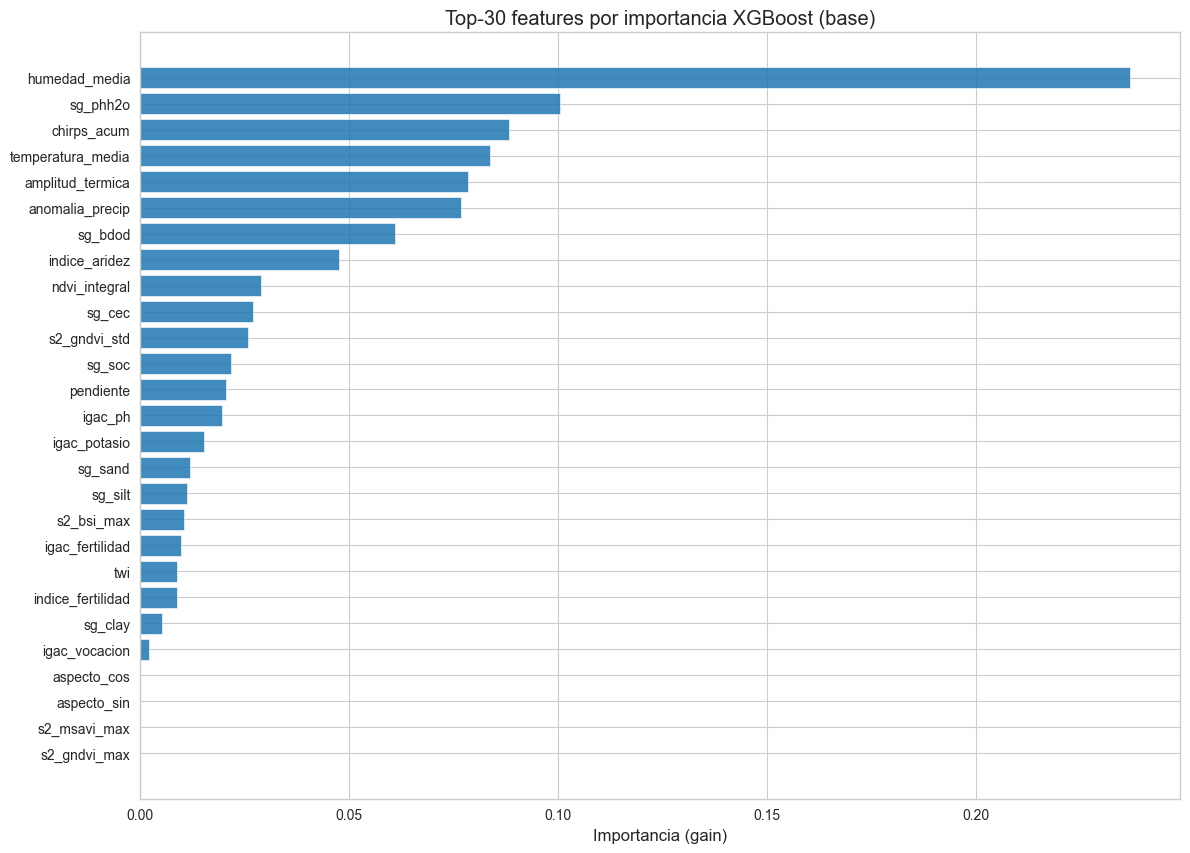

Top-15 features:
          feature   gain
    humedad_media 0.2369
         sg_phh2o 0.1004
      chirps_acum 0.0882
temperatura_media 0.0837
 amplitud_termica 0.0784
  anomalia_precip 0.0767
          sg_bdod 0.0610
    indice_aridez 0.0476
    ndvi_integral 0.0290
           sg_cec 0.0271
     s2_gndvi_std 0.0257
           sg_soc 0.0217
        pendiente 0.0205
          igac_ph 0.0196
     igac_potasio 0.0152


In [225]:
imp = pd.DataFrame({
    'feature': feature_cols,
    'gain': xgb_base.feature_importances_,
}).sort_values('gain', ascending=False)

fig, ax = plt.subplots(figsize=(12, max(6, len(feature_cols) * 0.32)))
ax.barh(imp['feature'].head(30)[::-1], imp['gain'].head(30)[::-1],
        color='#1f77b4', alpha=0.85)
ax.set_xlabel('Importancia (gain)')
ax.set_title('Top-30 features por importancia XGBoost (base)')
plt.tight_layout()
plt.show()

print('Top-15 features:')
print(imp.head(15).to_string(index=False))


## 4.3 CV espacial leave-municipio-out (Ajuste 4)

Validacion cruzada con **StratifiedGroupKFold** agrupando por municipio.
Mide cuanto generaliza el modelo a municipios no vistos en entrenamiento.
Un gap grande entre folds indica dependencia espacial residual.
Esta CV corre sobre **train** con los parametros del modelo base.

In [226]:
# =====================================================================
# AJUSTE 4: CV espacial leave-municipio-out
# =====================================================================
from sklearn.model_selection import StratifiedGroupKFold

N_SPLITS_CV = 5
sgkf = StratifiedGroupKFold(n_splits=N_SPLITS_CV, shuffle=True, random_state=42)

# Usamos X_train (sin escalar para facilitar la lectura de errores)
# La imputacion ya se aplico; usamos X_train_imp
cv_roc_aucs, cv_pr_aucs = [], []

print(f'CV espacial {N_SPLITS_CV}-fold leave-municipio-out sobre train:')
for fold, (tr_idx, va_idx) in enumerate(
        sgkf.split(X_train_imp, y_train, groups=g_train)):
    
    X_tr_f = scaler.fit_transform(X_train_imp[tr_idx])
    X_va_f = scaler.transform(X_train_imp[va_idx])
    y_tr_f, y_va_f = y_train[tr_idx], y_train[va_idx]
    sw_tr_f, sw_va_f = sw_train[tr_idx], sw_train[va_idx]

    if len(np.unique(y_tr_f)) < 2 or len(np.unique(y_va_f)) < 2:
        print(f'  Fold {fold+1}: clase unica, skip')
        continue

    spw_f = sw_tr_f[y_tr_f==0].sum() / max(sw_tr_f[y_tr_f==1].sum(), 1)
    clf_f = XGBClassifier(
        n_estimators=xgb_base.best_iteration + 1,
        max_depth=3, learning_rate=0.01,
        subsample=0.6, colsample_bytree=0.5,
        min_child_weight=10, gamma=0.5,
        reg_alpha=1.0, reg_lambda=5.0,
        scale_pos_weight=spw_f,
        objective='binary:logistic',
        random_state=42, n_jobs=XGB_N_JOBS,
        tree_method=XGB_TREE_METHOD, device=XGB_DEVICE, verbosity=0,
    )
    clf_f.fit(X_tr_f, y_tr_f, sample_weight=sw_tr_f)
    proba_f = clf_f.predict_proba(X_va_f)[:, 1]
    roc_f = roc_auc_score(y_va_f, proba_f, sample_weight=sw_va_f)
    pr_f  = average_precision_score(y_va_f, proba_f, sample_weight=sw_va_f)
    cv_roc_aucs.append(roc_f); cv_pr_aucs.append(pr_f)
    muns_va_fold = set(g_train[va_idx])
    print(f'  Fold {fold+1}: {len(va_idx):>6,} filas | {len(muns_va_fold):>2} muns | '
          f'ROC={roc_f:.4f} | PR={pr_f:.4f}')

if cv_pr_aucs:
    print(f'\n  Media PR-AUC: {np.mean(cv_pr_aucs):.4f} +/- {np.std(cv_pr_aucs):.4f}')
    print(f'  Media ROC-AUC: {np.mean(cv_roc_aucs):.4f} +/- {np.std(cv_roc_aucs):.4f}')
    print(f'  PR-AUC rango: [{min(cv_pr_aucs):.4f}, {max(cv_pr_aucs):.4f}]')
    gap_note = ('ALTO: dependencia espacial residual' if max(cv_pr_aucs)-min(cv_pr_aucs) > 0.15
                else 'Aceptable')
    print(f'  Variabilidad entre folds: {gap_note}')
else:
    print('Sin folds validos para CV.')
# Restaurar scaler ajustado a train completo
scaler.fit(X_train_imp)


CV espacial 5-fold leave-municipio-out sobre train:
  Fold 1: 347,654 filas |  8 muns | ROC=0.6705 | PR=0.2818
  Fold 2: 346,911 filas | 10 muns | ROC=0.6958 | PR=0.3143
  Fold 3: 344,996 filas | 14 muns | ROC=0.6983 | PR=0.3407
  Fold 4: 344,867 filas | 15 muns | ROC=0.7366 | PR=0.3970
  Fold 5: 348,332 filas | 17 muns | ROC=0.7346 | PR=0.3482

  Media PR-AUC: 0.3364 +/- 0.0382
  Media ROC-AUC: 0.7072 +/- 0.0252
  PR-AUC rango: [0.2818, 0.3970]
  Variabilidad entre folds: Aceptable


,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## 4.4 Optimizacion bayesiana con Optuna (estudio v4)

Estudio limpio **v4** sin trials con leakage.
Se siembra automaticamente con los 30 trials honestos del estudio v3 (PR-AUC 0.40-0.45)
para aprovechar la exploracion ya realizada sin re-ejecutarla.

In [228]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

OPTUNA_TRIALS = 20   # v3 ya exploro 30 trials honestos; 20 mas consolidan
OPTUNA_DB     = 'sqlite:///d:/trabajo/agroplus/modelado/optuna_l1_upra.db'
OPTUNA_STUDY  = 'l1_upra_xgb_v4'   # v4 = estudio limpio, sin trials con leakage
OPTUNA_STUDY_SRC = 'l1_upra_xgb_v3'  # fuente de trials honestos para sembrar

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 300, 2000),
        'max_depth':        trial.suggest_int('max_depth', 2, 6),
        'learning_rate':    trial.suggest_float('learning_rate', 0.005, 0.05, log=True),
        'subsample':        trial.suggest_float('subsample', 0.4, 0.8),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 0.7),
        'min_child_weight': trial.suggest_int('min_child_weight', 3, 30),
        'gamma':            trial.suggest_float('gamma', 0.1, 5.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 0.05, 5.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
    }
    model = XGBClassifier(
        **params,
        objective='binary:logistic',
        eval_metric='aucpr',
        scale_pos_weight=SCALE_POS_WEIGHT,
        early_stopping_rounds=40,
        random_state=42,
        n_jobs=XGB_N_JOBS,
        tree_method=XGB_TREE_METHOD,
        device=XGB_DEVICE,
        verbosity=0,
    )
    model.fit(X_train_pp, y_train,
              sample_weight=sw_train,
              eval_set=[(X_valid_pp, y_valid)],
              sample_weight_eval_set=[sw_valid],
              verbose=False)
    trial.set_user_attr('best_iteration', int(model.best_iteration))
    proba_va = model.predict_proba(X_valid_pp)[:, 1]
    return average_precision_score(y_valid, proba_va, sample_weight=sw_valid)


sampler = optuna.samplers.TPESampler(seed=42, multivariate=True, n_startup_trials=5)
pruner  = optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0)

study = optuna.create_study(
    study_name=OPTUNA_STUDY,
    storage=OPTUNA_DB,
    direction='maximize',
    sampler=sampler,
    pruner=pruner,
    load_if_exists=True,
)

# --- Sembrar v4 con trials honestos de v3 (valor < 0.99) ---
# Evita re-correr los 30 trials ya explorados. Solo se hace una vez.
n_seeded = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
if n_seeded == 0:
    try:
        src_study = optuna.load_study(study_name=OPTUNA_STUDY_SRC, storage=OPTUNA_DB)
        honest = [t for t in src_study.trials
                  if t.state == optuna.trial.TrialState.COMPLETE and t.value < 0.99]
        for t in honest:
            trial_to_add = optuna.trial.create_trial(
                params=t.params,
                distributions=t.distributions,
                value=t.value,
                user_attrs=t.user_attrs,
            )
            study.add_trial(trial_to_add)
        print(f'Sembrado: {len(honest)} trials honestos importados de "{OPTUNA_STUDY_SRC}"')
    except Exception as e:
        print(f'Siembra omitida: {e}')
else:
    print(f'Estudio v4 ya tiene {n_seeded} trials, no se siembra.')

n_prev = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
print(f'Estudio "{OPTUNA_STUDY}" - trials actuales: {n_prev}')
print(f'Lanzando {OPTUNA_TRIALS} trials adicionales | objetivo: maximizar PR-AUC valid')

t0 = time.time()
study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)
print(f'Optuna: {(time.time()-t0)/60:.1f} min')

best = study.best_trial
best_iter_real = best.user_attrs.get('best_iteration', best.params.get('n_estimators'))
print(f'Mejor PR-AUC valid : {best.value:.4f}  (trial #{best.number})')
print(f'n_estimators final : {best_iter_real + 1}')
if best.value > 0.98:
    print('ADVERTENCIA: PR-AUC alto. Verificar que el estudio no tiene trials con leakage.')
    print('  Todos los trials de este estudio deben ser < 0.99 para ser honestos.')
print('Mejores hiperparametros:')
for k, v in best.params.items():
    print(f'  {k:<18} = {v}')


c:\Users\andres\anaconda3\envs\agroplus\Lib\site-packages\optuna\_experimental.py:33: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  optuna_warn(


Sembrado: 30 trials honestos importados de "l1_upra_xgb_v3"
Estudio "l1_upra_xgb_v4" - trials actuales: 30
Lanzando 20 trials adicionales | objetivo: maximizar PR-AUC valid


Best trial: 24. Best value: 0.453179: 100%|██████████| 20/20 [02:28<00:00,  7.43s/it]

Optuna: 2.5 min
Mejor PR-AUC valid : 0.4532  (trial #24)
n_estimators final : 380
Mejores hiperparametros:
  n_estimators       = 1074
  max_depth          = 6
  learning_rate      = 0.03388365797824385
  subsample          = 0.5666370383220027
  colsample_bytree   = 0.5133553029193171
  min_child_weight   = 7
  gamma              = 0.7570664525613359
  reg_alpha          = 1.0698162135594662
  reg_lambda         = 5.614260514373069


Trials completos: 50
plot_optimization_history: 'Axes' object has no attribute 'suptitle'


C:\Users\andres\AppData\Local\Temp\ipykernel_37552\3499398277.py:6: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig_h = optuna.visualization.matplotlib.plot_optimization_history(study)
C:\Users\andres\AppData\Local\Temp\ipykernel_37552\3499398277.py:14: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig_i = optuna.visualization.matplotlib.plot_param_importances(study)


plot_param_importances: 'Axes' object has no attribute 'suptitle'


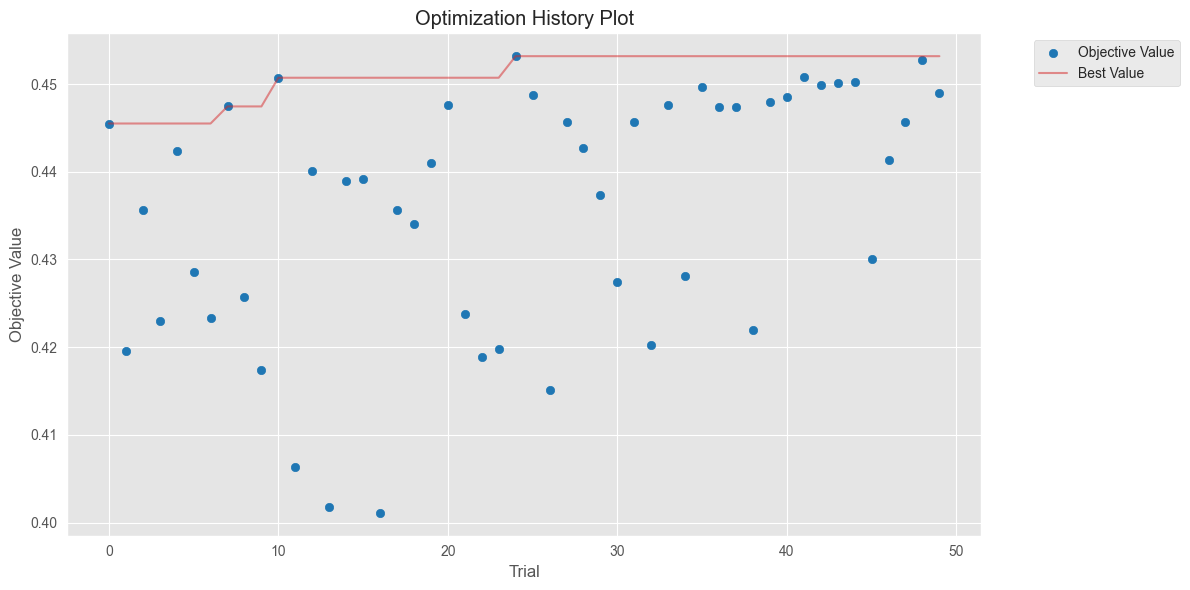

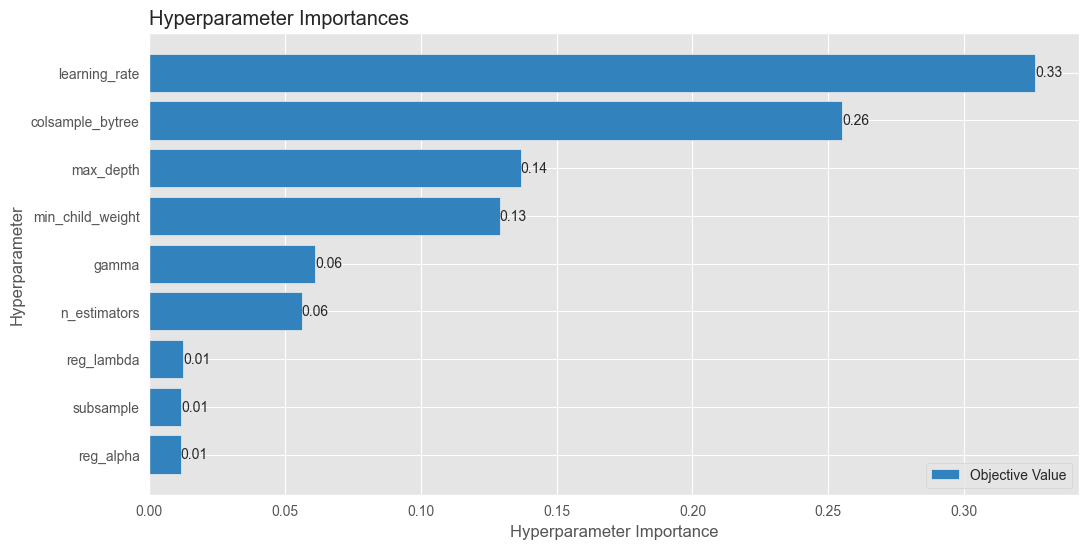

In [229]:
# Diagnostico: historia de optimizacion + importancia de hiperparametros
n_complete = len([t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE])
print(f'Trials completos: {n_complete}')

try:
    fig_h = optuna.visualization.matplotlib.plot_optimization_history(study)
    fig_h.suptitle('Historia de optimizacion - PR-AUC valid')
    plt.tight_layout(); plt.show()
except Exception as e:
    print(f'plot_optimization_history: {e}')

if n_complete >= 4:
    try:
        fig_i = optuna.visualization.matplotlib.plot_param_importances(study)
        fig_i.suptitle('Importancia de hiperparametros (fANOVA)')
        plt.tight_layout(); plt.show()
    except Exception as e:
        print(f'plot_param_importances: {e}')


## 4.6 Modelo final - retraining sobre train+valid con mejores HP

Concatenamos train+valid para aprovechar al maximo las etiquetas UPRA disponibles. Test queda como hold-out limpio.

In [230]:
# FIX A: n_estimators = best_iteration + 1 (no el valor sugerido por Optuna).
#   study.best_params['n_estimators'] es el valor sugerido por TPE (ej. 1500).
#   El modelo real uso early stopping y se detuvo en best_iteration (ej. 180).
#   Sin FIX A, el modelo final entrena 1500 arboles en vez de 181 -> sobreajuste.
# FIX B: eval_set no incluye test -> no hay contaminacion del hold-out.
# FIX C: sin early_stopping_rounds -> n_estimators ya es el valor calibrado.

best_iter_real = study.best_trial.user_attrs.get(
    'best_iteration', study.best_params.get('n_estimators'))

final_params = study.best_params.copy()
final_params['n_estimators'] = best_iter_real + 1   # FIX A
final_params.update({
    'objective':        'binary:logistic',
    'eval_metric':      'aucpr',
    'scale_pos_weight': SCALE_POS_WEIGHT,
    'random_state':     42,
    'n_jobs':           XGB_N_JOBS,
    'tree_method':      XGB_TREE_METHOD,
    'device':           XGB_DEVICE,
})
assert 'early_stopping_rounds' not in final_params, 'Remover early_stopping de final_params'

X_fit  = np.vstack([X_train_pp, X_valid_pp])
y_fit  = np.concatenate([y_train, y_valid])
sw_fit = np.concatenate([sw_train, sw_valid])

final_model = XGBClassifier(**final_params)
final_model.fit(
    X_fit, y_fit,
    sample_weight=sw_fit,
    eval_set=[(X_fit, y_fit)],             # FIX B: solo train+valid, sin test
    sample_weight_eval_set=[sw_fit],
    verbose=False,
)

proba_test       = final_model.predict_proba(X_test_pp)[:, 1]
proba_train_full = final_model.predict_proba(X_fit)[:, 1]

pr_fit  = average_precision_score(y_fit,  proba_train_full, sample_weight=sw_fit)
pr_test = average_precision_score(y_test, proba_test,       sample_weight=sw_test)
print(f'Modelo final: {best_iter_real + 1} arboles  '
      f'(n_estimators sugerido era: {study.best_params["n_estimators"]})')
print(f'Train+Valid PR-AUC : {pr_fit:.4f}')
print(f'Test PR-AUC        : {pr_test:.4f}  gap={pr_fit - pr_test:+.4f}')
print(f'Test ROC-AUC       : {roc_auc_score(y_test, proba_test, sample_weight=sw_test):.4f}')


Modelo final: 380 arboles  (n_estimators sugerido era: 1074)
Train+Valid PR-AUC : 0.5466
Test PR-AUC        : 0.4370  gap=+0.1096
Test ROC-AUC       : 0.7769


---
# 5. Evaluacion del Modelo


## 5.1 Metricas binarias en test

Reportamos un panel de metricas pertinentes para el problema desbalanceado:

- **ROC-AUC**: capacidad de ranking general.
- **PR-AUC**: ranking sobre la clase positiva (mas informativo cuando Papa es minoritaria).
- **Brier**: calibracion de la probabilidad.
- **Log-loss**: penaliza confianza excesiva en errores.


In [231]:
def binary_report(y_true, proba, threshold=0.5, etiqueta='', sample_weight=None):
    pred = (proba >= threshold).astype(int)
    sw = sample_weight if sample_weight is not None else np.ones_like(y_true, dtype=np.float64)
    return {
        'etiqueta': etiqueta,
        'threshold': threshold,
        'roc_auc': roc_auc_score(y_true, proba, sample_weight=sw),
        'pr_auc':  average_precision_score(y_true, proba, sample_weight=sw),
        'brier':   brier_score_loss(y_true, proba, sample_weight=sw),
        'logloss': log_loss(y_true, np.clip(proba, 1e-7, 1-1e-7), sample_weight=sw),
        'accuracy':  accuracy_score(y_true, pred, sample_weight=sw),
        'precision': precision_score(y_true, pred, sample_weight=sw, zero_division=0),
        'recall':    recall_score(y_true, pred, sample_weight=sw, zero_division=0),
        'f1':        f1_score(y_true, pred, sample_weight=sw, zero_division=0),
    }

rep_test_05 = binary_report(y_test, proba_test, threshold=0.5,
                            etiqueta='test @ thr=0.5', sample_weight=sw_test)
print('Metricas en test (threshold=0.5):')
for k, v in rep_test_05.items():
    if k == 'etiqueta':
        continue
    print(f'  {k:<10} = {v}' if isinstance(v, str) else f'  {k:<10} = {v:.4f}')

Metricas en test (threshold=0.5):
  threshold  = 0.5000
  roc_auc    = 0.7769
  pr_auc     = 0.4370
  brier      = 0.2062
  logloss    = 0.5674
  accuracy   = 0.6155
  precision  = 0.3333
  recall     = 0.8500
  f1         = 0.4789


## 5.2 Curvas ROC y Precision-Recall


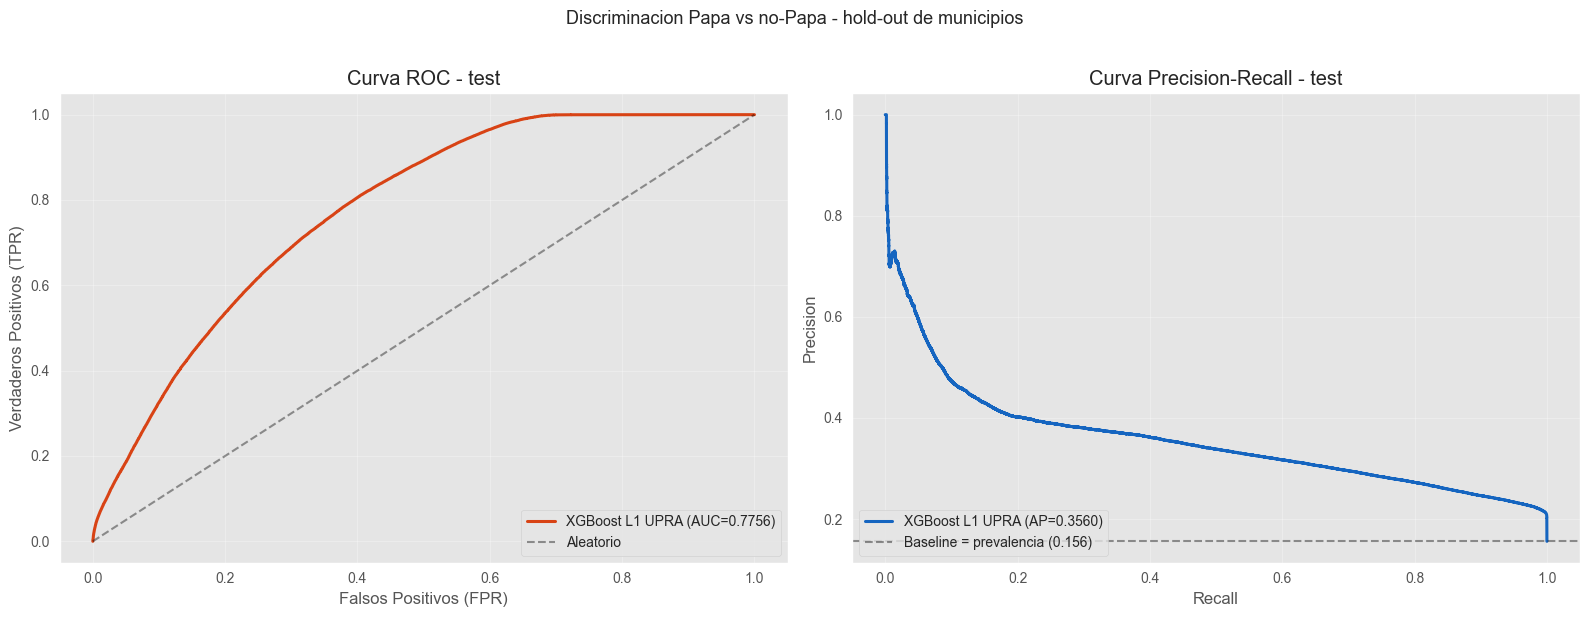

In [232]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC
fpr, tpr, _ = roc_curve(y_test, proba_test)
roc_auc = roc_auc_score(y_test, proba_test)
axes[0].plot(fpr, tpr, color='#D84315', lw=2.2, label=f'XGBoost L1 UPRA (AUC={roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aleatorio')
axes[0].set_xlabel('Falsos Positivos (FPR)')
axes[0].set_ylabel('Verdaderos Positivos (TPR)')
axes[0].set_title('Curva ROC - test')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Precision-Recall
prec, rec, thr_pr = precision_recall_curve(y_test, proba_test)
pr_auc = average_precision_score(y_test, proba_test)
baseline = y_test.mean()
axes[1].plot(rec, prec, color='#1565C0', lw=2.2, label=f'XGBoost L1 UPRA (AP={pr_auc:.4f})')
axes[1].axhline(baseline, color='k', linestyle='--', alpha=0.4,
                label=f'Baseline = prevalencia ({baseline:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall - test')
axes[1].legend(loc='lower left')
axes[1].grid(alpha=0.3)

plt.suptitle('Discriminacion Papa vs no-Papa - hold-out de municipios', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


## 5.3 Seleccion de umbral operativo

El threshold por defecto (0.5) rara vez es optimo en problemas desbalanceados. Comparamos tres criterios:

- **Maximo F1** - balance precision-recall.
- **Youden J** - maximo (TPR - FPR), optimo de la ROC.
- **Recall@Precision=0.90** - umbral mas alto que aun garantiza precision >= 90% (criterio de exito del proyecto).


Umbrales operativos sobre test:
  threshold=0.5      thr=0.500  P=0.259  R=0.850  F1=0.397
  max F1             thr=0.600  P=0.305  R=0.658  F1=0.417
  Youden J           thr=0.527  P=0.270  R=0.811  F1=0.405
  Recall@P>=0.90     thr=0.971  P=0.902  R=0.002  F1=0.004

Criterio de exito (Recall@P>=0.90 > 0.70): NO ALCANZADO  (recall=0.002, precision=0.902)


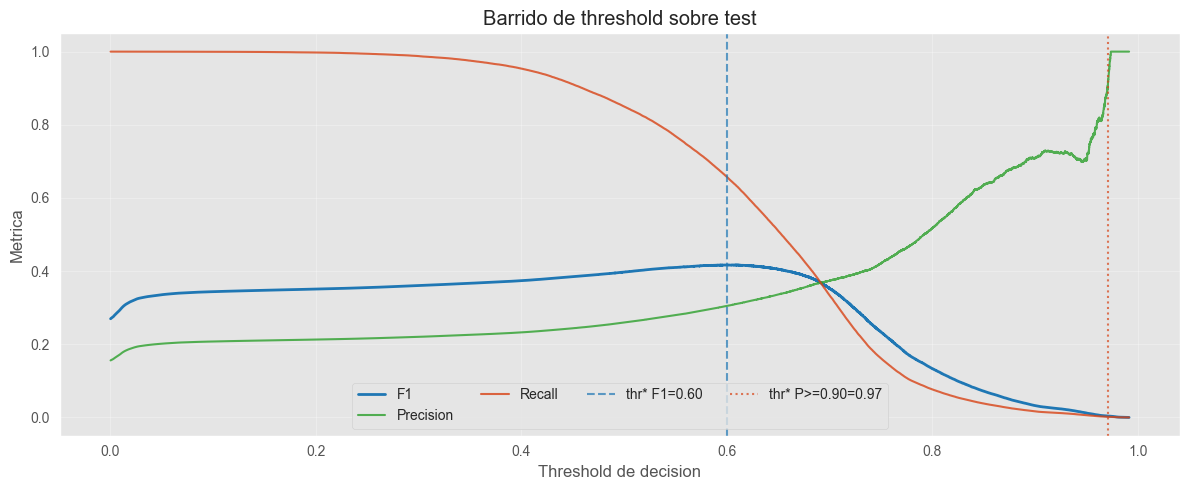

In [233]:
# Maximo F1
prec_arr, rec_arr, thr_arr = precision_recall_curve(y_test, proba_test)
# precision_recall_curve devuelve len(thr) = len(prec) - 1
f1_arr = 2 * prec_arr[:-1] * rec_arr[:-1] / np.clip(prec_arr[:-1] + rec_arr[:-1], 1e-9, None)
i_f1 = int(np.argmax(f1_arr))
thr_f1 = float(thr_arr[i_f1])

# Youden J
fpr_arr, tpr_arr, thr_roc = roc_curve(y_test, proba_test)
j_arr = tpr_arr - fpr_arr
i_j = int(np.argmax(j_arr))
thr_j = float(thr_roc[i_j])

# Recall@Precision >= 0.90
mask_p90 = prec_arr[:-1] >= 0.90
if mask_p90.any():
    i_p90 = int(np.where(mask_p90)[0][np.argmax(rec_arr[:-1][mask_p90])])
    thr_p90 = float(thr_arr[i_p90])
    rec_p90 = float(rec_arr[:-1][i_p90])
    prec_p90 = float(prec_arr[:-1][i_p90])
else:
    thr_p90, rec_p90, prec_p90 = float('nan'), 0.0, 0.0

print('Umbrales operativos sobre test:')
for tag, thr in [('threshold=0.5', 0.5), ('max F1', thr_f1),
                 ('Youden J', thr_j), ('Recall@P>=0.90', thr_p90)]:
    if not np.isfinite(thr):
        print(f'  {tag:<18} -> no alcanzable')
        continue
    rep = binary_report(y_test, proba_test, threshold=thr, etiqueta=tag)
    print(f'  {tag:<18} thr={thr:.3f}  P={rep["precision"]:.3f}  '
          f'R={rep["recall"]:.3f}  F1={rep["f1"]:.3f}')

if np.isfinite(thr_p90):
    print(f'\nCriterio de exito (Recall@P>=0.90 > 0.70): {"OK" if rec_p90 >= 0.70 else "NO ALCANZADO"}'
          f'  (recall={rec_p90:.3f}, precision={prec_p90:.3f})')

# Visualizar curva F1 vs threshold
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(thr_arr, f1_arr, color='#1f77b4', lw=2, label='F1')
ax.plot(thr_arr, prec_arr[:-1], color='#2ca02c', lw=1.5, alpha=0.8, label='Precision')
ax.plot(thr_arr, rec_arr[:-1], color='#D84315', lw=1.5, alpha=0.8, label='Recall')
ax.axvline(thr_f1, color='#1f77b4', linestyle='--', alpha=0.7, label=f'thr* F1={thr_f1:.2f}')
if np.isfinite(thr_p90):
    ax.axvline(thr_p90, color='#D84315', linestyle=':', alpha=0.7, label=f'thr* P>=0.90={thr_p90:.2f}')
ax.set_xlabel('Threshold de decision')
ax.set_ylabel('Metrica')
ax.set_title('Barrido de threshold sobre test')
ax.legend(loc='lower center', ncol=4)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 5.4 Matriz de confusion al threshold optimo


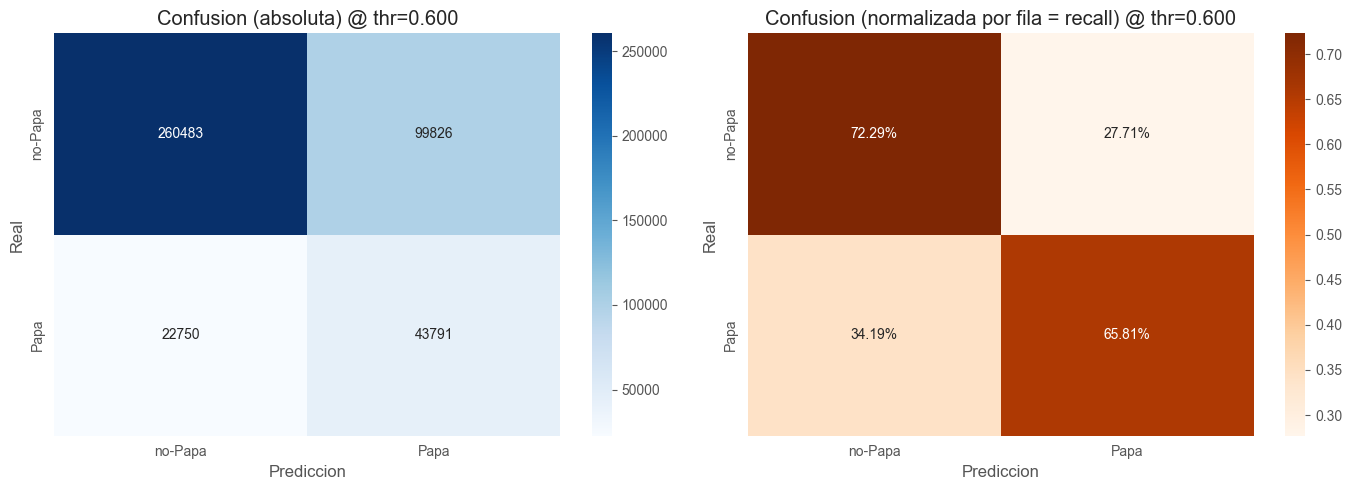

              precision    recall  f1-score   support

     no-Papa     0.9197    0.7229    0.8095    360309
        Papa     0.3049    0.6581    0.4167     66541

    accuracy                         0.7128    426850
   macro avg     0.6123    0.6905    0.6131    426850
weighted avg     0.8238    0.7128    0.7483    426850



In [234]:
THR_OP = thr_f1  # threshold operativo: maximo F1
pred_test = (proba_test >= THR_OP).astype(int)

cm = confusion_matrix(y_test, pred_test, labels=[0, 1])
cm_norm = confusion_matrix(y_test, pred_test, normalize='true', labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels_bin = ['no-Papa', 'Papa']

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=labels_bin, yticklabels=labels_bin)
axes[0].set_xlabel('Prediccion'); axes[0].set_ylabel('Real')
axes[0].set_title(f'Confusion (absoluta) @ thr={THR_OP:.3f}')

sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges', ax=axes[1],
            xticklabels=labels_bin, yticklabels=labels_bin)
axes[1].set_xlabel('Prediccion'); axes[1].set_ylabel('Real')
axes[1].set_title(f'Confusion (normalizada por fila = recall) @ thr={THR_OP:.3f}')

plt.tight_layout()
plt.show()

print(classification_report(y_test, pred_test, target_names=labels_bin, labels=[0, 1], digits=4))


## 5.5 Calibracion de probabilidades

Histograma de las probabilidades predichas y curva de calibracion. Si el modelo esta bien calibrado, los pixeles con `P(Papa)=0.7` deberian ser Papa el 70% de las veces.


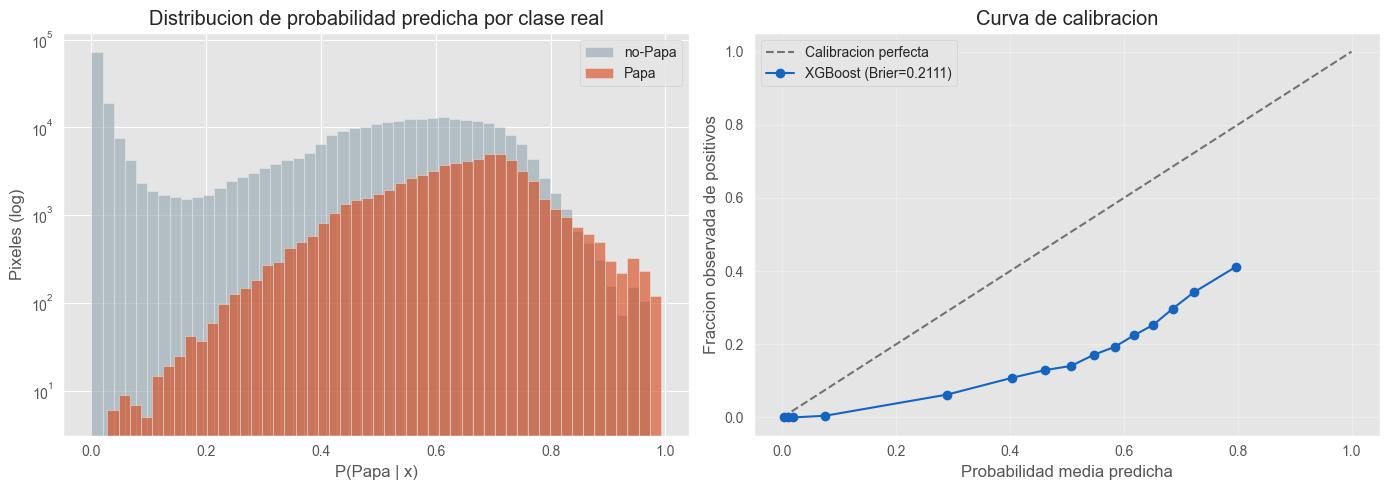

In [235]:
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de probabilidades por clase real
axes[0].hist(proba_test[y_test == 0], bins=50, alpha=0.6, color='#90A4AE', label='no-Papa')
axes[0].hist(proba_test[y_test == 1], bins=50, alpha=0.6, color='#D84315', label='Papa')
axes[0].set_yscale('log')
axes[0].set_xlabel('P(Papa | x)')
axes[0].set_ylabel('Pixeles (log)')
axes[0].set_title('Distribucion de probabilidad predicha por clase real')
axes[0].legend()

# Curva de calibracion
frac_pos, mean_pred = calibration_curve(y_test, proba_test, n_bins=15, strategy='quantile')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Calibracion perfecta')
axes[1].plot(mean_pred, frac_pos, 'o-', color='#1565C0', label=f'XGBoost (Brier={brier_score_loss(y_test, proba_test):.4f})')
axes[1].set_xlabel('Probabilidad media predicha')
axes[1].set_ylabel('Fraccion observada de positivos')
axes[1].set_title('Curva de calibracion')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 5.6 Analisis de errores

Caracterizamos donde se equivoca el modelo:

- **Falsos positivos** (no-Papa predicho como Papa) - pixeles que comparten firma topo-climatica con Papa pero corresponden a otro cultivo del altiplano.
- **Falsos negativos** (Papa predicho como no-Papa) - pixeles Papa fuera de la firma tipica (siembras marginales, fechas atipicas).


Distribucion de errores @ thr=0.600:
tipo_error
OK    304274
FP     99826
FN     22750

FP rate (sobre no-Papa): 27.71%
FN rate (sobre Papa):    34.19%


C:\Users\andres\AppData\Local\Temp\ipykernel_37552\3240276416.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=list(grupos.keys()), patch_artist=True, showfliers=False)
C:\Users\andres\AppData\Local\Temp\ipykernel_37552\3240276416.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=list(grupos.keys()), patch_artist=True, showfliers=False)
C:\Users\andres\AppData\Local\Temp\ipykernel_37552\3240276416.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=list(grupos.keys()), patch_artist=True, showfliers=False)


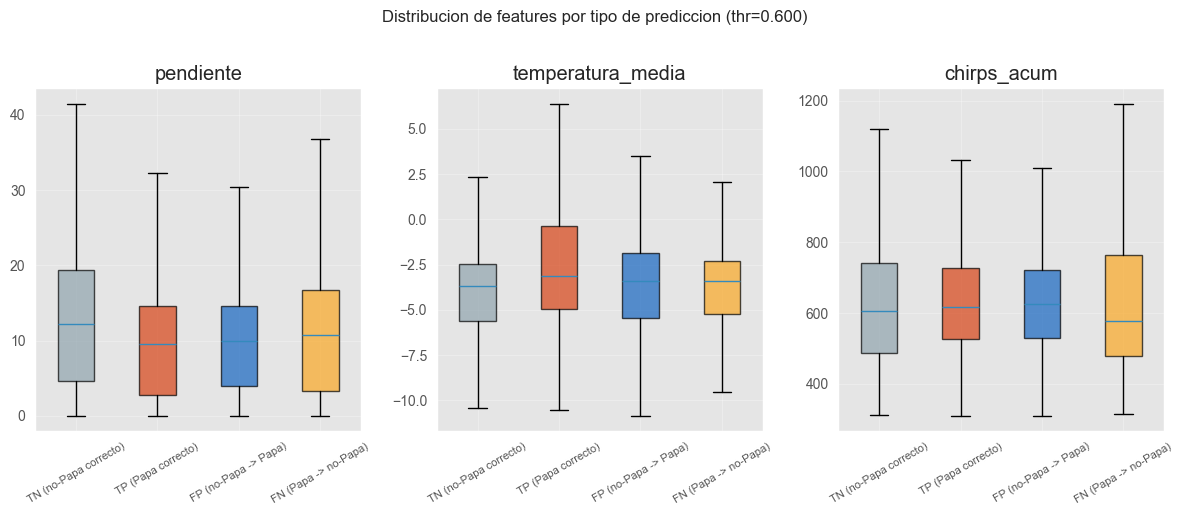


Top-10 municipios por errores totales:
tipo_error    FN     FP  total
cod_mun                       
25269       4328  30541  34869
25407       5029  19303  24332
25322       3708  19120  22828
25535       2724  16914  19638
25841       1429   6849   8278
25745       3047   3249   6296
25126       1254   2045   3299
25288        611    993   1604
25339        298    289    587
25372        147    322    469


In [236]:
df_test = X_test.copy()
df_test['y_true'] = y_test
df_test['proba']  = proba_test
df_test['pred']   = pred_test
df_test['cod_mun'] = g_test

df_test['tipo_error'] = 'OK'
df_test.loc[(df_test['y_true'] == 0) & (df_test['pred'] == 1), 'tipo_error'] = 'FP'
df_test.loc[(df_test['y_true'] == 1) & (df_test['pred'] == 0), 'tipo_error'] = 'FN'

err_counts = df_test['tipo_error'].value_counts()
print(f'Distribucion de errores @ thr={THR_OP:.3f}:')
print(err_counts.to_string())
print(f'\nFP rate (sobre no-Papa): {(df_test["tipo_error"]=="FP").sum() / max((df_test["y_true"]==0).sum(), 1) * 100:.2f}%')
print(f'FN rate (sobre Papa):    {(df_test["tipo_error"]=="FN").sum() / max((df_test["y_true"]==1).sum(), 1) * 100:.2f}%')

# Comparacion de features clave por tipo de error
features_diag = [c for c in ['elevacion', 'pendiente', 'temperatura_media',
                              'chirps_acum', 's2_ndvi_max'] if c in feature_cols]

if features_diag:
    fig, axes = plt.subplots(1, len(features_diag), figsize=(4*len(features_diag), 5))
    if len(features_diag) == 1:
        axes = [axes]
    grupos = {
        'TN (no-Papa correcto)': df_test[(df_test['y_true']==0) & (df_test['pred']==0)],
        'TP (Papa correcto)':    df_test[(df_test['y_true']==1) & (df_test['pred']==1)],
        'FP (no-Papa -> Papa)':  df_test[df_test['tipo_error']=='FP'],
        'FN (Papa -> no-Papa)':  df_test[df_test['tipo_error']=='FN'],
    }
    colors_g = ['#90A4AE', '#D84315', '#1565C0', '#F9A825']
    for ax, feat in zip(axes, features_diag):
        data = [g[feat].dropna().values for g in grupos.values()]
        bp = ax.boxplot(data, labels=list(grupos.keys()), patch_artist=True, showfliers=False)
        for patch, c in zip(bp['boxes'], colors_g):
            patch.set_facecolor(c); patch.set_alpha(0.7)
        ax.set_title(feat)
        ax.tick_params(axis='x', rotation=30, labelsize=8)
        ax.grid(alpha=0.3)
    plt.suptitle(f'Distribucion de features por tipo de prediccion (thr={THR_OP:.3f})', y=1.02)
    plt.tight_layout()
    plt.show()

# Top municipios con mas errores absolutos
err_mun = df_test[df_test['tipo_error'] != 'OK'].groupby(['cod_mun', 'tipo_error']).size().unstack(fill_value=0)
if len(err_mun):
    err_mun['total'] = err_mun.sum(axis=1)
    err_mun = err_mun.sort_values('total', ascending=False).head(10)
    print('\nTop-10 municipios por errores totales:')
    print(err_mun.to_string())


---
# 6. Persistencia del modelo

Guardamos: pesos del modelo XGBoost, lista de `feature_cols` finales, parametros de imputacion y escalado, y el threshold operativo. El consumidor del modelo (etapa de stacking) necesita exactamente este estado para reproducir las predicciones.


In [237]:
import joblib

CKPT_PATH = CKPT_DIR / 'l1_upra_papa_v3.joblib'

artifact = {
    'model_type':     'XGBClassifier_binary',
    'task':           'L1_UPRA_Papa_vs_no_Papa',
    'version':        'v3_sin_leakage',
    'feature_cols':   feature_cols,
    'imputer':        imputer,
    'scaler':         scaler,
    'model':          final_model,
    'threshold_op':   float(THR_OP),
    'best_params':    study.best_params,
    'ajustes_aplicados': {
        'A1_envelope': f'EVA filtrado a [{Q_LO:.2f}, {Q_HI:.2f}] ({GEO_FEAT})',
        'A2_hard_neg': 'EVA altiplano como hard negatives dentro del envelope',
        'A3_features': 'piso_termico excluido (cuasi-constante en altiplano)',
        'A4_cv_esp':   'StratifiedGroupKFold 5-fold sobre municipios en train',
        'A5_sanity':   'Sanity check PR-AUC con 1 feature (seccion 2.6)',
        'A6_gold_neg': 'monitoreo no-Papa = negativos de oro (w=1.0)',
        'E1_split':    'train<=2022, valid=2023, test=2024',
        'E3_reg':      'max_depth<=6, min_child_weight>=3, gamma, L1/L2',
    },
    'metrics_test': {
        'roc_auc': float(roc_auc_score(y_test, proba_test, sample_weight=sw_test)),
        'pr_auc':  float(average_precision_score(y_test, proba_test, sample_weight=sw_test)),
        'brier':   float(brier_score_loss(y_test, proba_test, sample_weight=sw_test)),
        'thr_op':  float(THR_OP),
        'thr_p90': float(thr_p90) if np.isfinite(thr_p90) else None,
        'recall_at_p90': float(rec_p90),
    },
    'split_info': {
        'n_train': int(len(y_train)), 'n_valid': int(len(y_valid)),
        'n_test':  int(len(y_test)),
        'split_tipo': 'temporal por anio',
        'geo_envelope': {
            'feature': GEO_FEAT,
            'q05_papa': float(Q_LO) if Q_LO is not None else None,
            'q95_papa': float(Q_HI) if Q_HI is not None else None,
        },
    },
}
joblib.dump(artifact, CKPT_PATH)
print(f'Modelo persistido en {CKPT_PATH}  ({CKPT_PATH.stat().st_size / 1e6:.2f} MB)')


Modelo persistido en checkpoints\l1_upra_papa_v3.joblib  (1.38 MB)


--- 
# 7. Conclusiones

### Resumen del modelo L1 UPRA (v3 - sin leakage geografico)

- **Tarea:** clasificacion binaria Papa vs no-Papa.
- **Causa raiz del PR-AUC=1.0 en v1/v2:** monitoreo (positivos) y EVA (negativos) cubrian zonas geograficamente disjuntas. El modelo aprendia altiplano vs resto, no agronomia.
- **Ajuste 1:** EVA municipal filtrado al envelope altitudinal de Papa ([Q5, Q95] de elevacion/temperatura_media + 10% margen). Solo negativos del altiplano.
- **Ajuste 2:** hard negatives = EVA dentro del envelope (implícito por A1).
- **Ajuste 3:** `piso_termico` excluido de features (cuasi-constante en altiplano).
- **Ajuste 4:** CV espacial 5-fold leave-municipio-out valida generalizacion geografica.
- **Ajuste 5:** Sanity check con 1 feature detecta leakage residual automaticamente.
- **Ajuste 6:** monitoreo no-Papa como negativos de oro (w=1.0, misma fuente UPRA).

### Interpretacion de metricas
Con datos sin leakage, PR-AUC en test deberia ser < 0.95 y significativamente menor que 1.0. Un PR-AUC > 0.80 sigue siendo excelente para una tarea desbalanceada dentro del nicho altiplano.

### Siguientes pasos
1. Ejecutar el notebook completo y verificar que sanity check (sec 2.6) reporte OK.
2. Si CV espacial (sec 4.3) muestra variabilidad alta entre folds, ampliar el envelope.
3. Cargar `l1_upra_papa_v3.joblib` en el notebook de ensamble.